# Phase 4: Domain-Specific DeepONet Models

## Overview

Phase 4 transitions from a single unified model to **four dedicated DeepONet models**, each specializing in one physical domain of the CDU thermal-hydraulic loop:

| Domain | Model | Outputs per CDU | Total Outputs | Key Feature |
|--------|-------|-----------------|---------------|-------------|
| **Temperature** ($G_T$) | Delta DeepONet | 4 (T_prim_s, T_prim_r, T_sec_s, T_sec_r) | 1028 | 3-layer LSTM, primary/secondary split |
| **Flow** ($G_V$) | Delta DeepONet | 2 (V_flow_prim, V_flow_sec) | 514 | Derivative loss, separate branch heads |
| **Pressure** ($G_p$) | Delta DeepONet | 4 (p_prim_s, p_prim_r, p_sec_s, p_sec_r) | 1028 | Skip connections, supply/return split |
| **Power** ($G_W$) | Delta DeepONet | 1 (W_flow_CDUP) | 257 | Skip connections, near-constant analysis |

### Shared Architecture Template (Section 5.4.1)

All domain models follow the same DeepONet template:

**Branch Network**
```
Input Projection → 2-layer LSTM (128 hidden) → LayerNorm → Attention Pooling → Linear → p×d basis coefficients
```

**Trunk Network**
```
Fourier Features (8 frequencies) → 2-layer MLP (64 hidden) → p=32 basis weights
```

**Output**
```
ŷ(t+k) = Σ_j b_j(u) · τ_j(t_k) · scale + bias → cumulative delta → absolute predictions
```

### Dataset
- **Systematic dataset**: `systematic_fmu_output_11hrs.parquet`
- **257 CDUs** with independent LHS-sampled inputs (~65 hours simulation)
- **Subsampled** at 30s intervals for training efficiency

### Training Configuration
- **Optimizer**: AdamW (lr=1e-3, weight_decay=1e-4)
- **Scheduler**: Cosine annealing with warm restarts (T₀=20, T_mult=2)
- **Loss**: Huber (δ=0.5) + optional derivative loss
- **Early stopping**: Patience 20 on validation loss
- **Data split**: 70/15/15 (temporal, no shuffle)

In [1]:
#  Imports and Device Configuration

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = min(16, os.cpu_count())
PIN_MEMORY = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla V100-PCIE-16GB
Memory: 16.9 GB


In [2]:
#  Domain Configurations

@dataclass
class DomainConfig:
    """Base configuration shared across all domain models."""
    # Data paths
    DOI: str = "" # Insert Correct DOI for the dataset
    DATA_NAME: str = "summit_10hrs_operational.parquet"
    NUM_CDUS: int = 257
    CDU_IDS: List[int] = field(default_factory=lambda: list(range(1, 258)))
    TIME_COL: str = 'time'

    # Temporal parameters
    SAMPLING_RATE_SEC: float = 1.0
    SUBSAMPLE_FACTOR: int = 30
    PREDICTION_SECONDS: int = 120

    @property
    def PREDICTION_STEPS(self) -> int:
        return int(self.PREDICTION_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    # Training parameters
    BATCH_SIZE: int = 64
    LEARNING_RATE: float = 1e-3
    WEIGHT_DECAY: float = 1e-4
    MAX_EPOCHS: int = 150
    PATIENCE: int = 20
    GRADIENT_CLIP: float = 1.0

    # Data splits
    TRAIN_RATIO: float = 0.7
    VAL_RATIO: float = 0.15
    TEST_RATIO: float = 0.15


@dataclass
class TemperatureConfig(DomainConfig):
    """Temperature domain (G_T): 4 outputs per CDU."""
    DOMAIN: str = 'temperature'
    HISTORY_SECONDS: int = 1200
    INCLUDE_OUTPUT_HISTORY: bool = True
    OUTPUT_HISTORY_STEPS: int = 2100

    # Architecture
    LSTM_LAYERS: int = 3
    DROPOUT: float = 0.4
    BRANCH_HIDDEN: int = 128
    TRUNK_HIDDEN: int = 64
    N_BASIS: int = 32
    N_FOURIER_FREQ: int = 8
    USE_SKIP_CONNECTION: bool = False
    USE_DERIVATIVE_LOSS: bool = False
    DERIVATIVE_WEIGHT: float = 0.0

    # Loss
    LOSS_TYPE: str = 'huber'
    HUBER_DELTA: float = 0.5

    # Outputs
    TEMPERATURE_OUTPUTS: List[str] = field(default_factory=lambda: [
        'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
    ])
    PRIMARY_TEMPS: List[str] = field(default_factory=lambda: ['T_prim_s_C', 'T_prim_r_C'])
    SECONDARY_TEMPS: List[str] = field(default_factory=lambda: ['T_sec_s_C', 'T_sec_r_C'])

    @property
    def HISTORY_STEPS(self) -> int:
        return int(self.HISTORY_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))


@dataclass
class FlowConfig(DomainConfig):
    """Flow domain (G_V): 2 outputs per CDU."""
    DOMAIN: str = 'flow'
    HISTORY_SECONDS: int = 1800
    INCLUDE_OUTPUT_HISTORY: bool = True
    OUTPUT_HISTORY_STEPS: int = 2100

    # Architecture
    LSTM_LAYERS: int = 2
    DROPOUT: float = 0.3
    BRANCH_HIDDEN: int = 128
    TRUNK_HIDDEN: int = 64
    N_BASIS: int = 32
    N_FOURIER_FREQ: int = 8
    USE_SKIP_CONNECTION: bool = False
    USE_SEPARATE_MODELS: bool = True
    USE_DERIVATIVE_LOSS: bool = True
    DERIVATIVE_WEIGHT: float = 0.1

    # Prediction modes
    PRIM_PREDICTION_MODE: str = 'delta'
    SEC_PREDICTION_MODE: str = 'delta'

    # Loss
    LOSS_TYPE: str = 'huber'
    HUBER_DELTA: float = 0.5

    # Outputs
    FLOW_OUTPUTS: List[str] = field(default_factory=lambda: [
        'V_flow_prim_GPM', 'V_flow_sec_GPM',
    ])

    @property
    def HISTORY_STEPS(self) -> int:
        return int(self.HISTORY_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))


@dataclass
class PressureConfig(DomainConfig):
    """Pressure domain (G_p): 4 outputs per CDU."""
    DOMAIN: str = 'pressure'
    HISTORY_SECONDS: int = 1200
    INCLUDE_OUTPUT_HISTORY: bool = True
    OUTPUT_HISTORY_STEPS: int = 2100

    # Architecture
    LSTM_LAYERS: int = 2
    DROPOUT: float = 0.3
    BRANCH_HIDDEN: int = 128
    TRUNK_HIDDEN: int = 64
    N_BASIS: int = 32
    N_FOURIER_FREQ: int = 8
    USE_SKIP_CONNECTION: bool = True
    INITIAL_SKIP_ALPHA: float = 0.5
    USE_DERIVATIVE_LOSS: bool = True
    DERIVATIVE_WEIGHT: float = 0.1

    # Prediction modes
    PRIM_PREDICTION_MODE: str = 'delta'
    SEC_PREDICTION_MODE: str = 'delta'

    # Loss
    LOSS_TYPE: str = 'huber'
    HUBER_DELTA: float = 0.5

    # Outputs
    PRESSURE_OUTPUTS: List[str] = field(default_factory=lambda: [
        'p_prim_s_psig', 'p_prim_r_psig', 'p_sec_s_psig', 'p_sec_r_psig',
    ])
    PRIMARY_PRESSURES: List[str] = field(default_factory=lambda: ['p_prim_s_psig', 'p_prim_r_psig'])
    SECONDARY_PRESSURES: List[str] = field(default_factory=lambda: ['p_sec_s_psig', 'p_sec_r_psig'])
    SUPPLY_PRESSURES: List[str] = field(default_factory=lambda: ['p_prim_s_psig', 'p_sec_s_psig'])
    RETURN_PRESSURES: List[str] = field(default_factory=lambda: ['p_prim_r_psig', 'p_sec_r_psig'])

    @property
    def HISTORY_STEPS(self) -> int:
        return int(self.HISTORY_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))


@dataclass
class PowerConfig(DomainConfig):
    """Power domain (G_W): 1 output per CDU."""
    DOMAIN: str = 'power'
    HISTORY_SECONDS: int = 1200
    INCLUDE_OUTPUT_HISTORY: bool = True
    OUTPUT_HISTORY_STEPS: int = 2100

    # Architecture
    LSTM_LAYERS: int = 2
    DROPOUT: float = 0.3
    BRANCH_HIDDEN: int = 128
    TRUNK_HIDDEN: int = 64
    N_BASIS: int = 32
    N_FOURIER_FREQ: int = 8
    USE_SKIP_CONNECTION: bool = True
    INITIAL_SKIP_ALPHA: float = 0.5
    USE_DERIVATIVE_LOSS: bool = True
    DERIVATIVE_WEIGHT: float = 0.1
    PREDICTION_MODE: str = 'delta'

    # Loss
    LOSS_TYPE: str = 'huber'
    HUBER_DELTA: float = 0.5

    # Outputs
    POWER_OUTPUTS: List[str] = field(default_factory=lambda: ['W_flow_CDUP_kW'])

    @property
    def HISTORY_STEPS(self) -> int:
        return int(self.HISTORY_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))


# Instantiate all domain configs
temp_config = TemperatureConfig()
flow_config = FlowConfig()
pressure_config = PressureConfig()
power_config = PowerConfig()

DOMAIN_CONFIGS = {
    'temperature': temp_config,
    'flow': flow_config,
    'pressure': pressure_config,
    'power': power_config,
}

# Print summary
for name, cfg in DOMAIN_CONFIGS.items():
    print(f"\n{name.upper()}: history={cfg.HISTORY_SECONDS}s ({cfg.HISTORY_STEPS} steps), "
          f"pred={cfg.PREDICTION_SECONDS}s ({cfg.PREDICTION_STEPS} steps), "
          f"LSTM={cfg.LSTM_LAYERS}L, hidden={cfg.BRANCH_HIDDEN}, basis={cfg.N_BASIS}")


TEMPERATURE: history=1200s (40 steps), pred=120s (4 steps), LSTM=3L, hidden=128, basis=32

FLOW: history=1800s (60 steps), pred=120s (4 steps), LSTM=2L, hidden=128, basis=32

PRESSURE: history=1200s (40 steps), pred=120s (4 steps), LSTM=2L, hidden=128, basis=32

POWER: history=1200s (40 steps), pred=120s (4 steps), LSTM=2L, hidden=128, basis=32


In [3]:
#  Normalizers

class ZScoreNormalizer:
    """Z-score (standardization) normalizer."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str]) -> 'ZScoreNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[:, i]
            self.stats[col] = {
                'mean': float(np.nanmean(col_data)),
                'std': float(np.nanstd(col_data) + 1e-8),
                'min': float(np.nanmin(col_data)),
                'max': float(np.nanmax(col_data)),
            }
        return self

    def transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        normalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            normalized[:, i] = (data[:, i] - s['mean']) / s['std']
        return normalized

    def inverse_transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        denormalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            denormalized[:, i] = data[:, i] * s['std'] + s['mean']
        return denormalized


class DeltaNormalizer:
    """Normalizer for delta (change) predictions."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str],
            subsample_factor: int = 1) -> 'DeltaNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[::subsample_factor, i]
            deltas = np.diff(col_data)
            self.stats[col] = {
                'delta_mean': float(np.nanmean(deltas)),
                'delta_std': float(np.nanstd(deltas) + 1e-10),
            }
        return self

    def get_scale(self, col: str) -> float:
        return self.stats[col]['delta_std'] * 10

    def print_stats(self, col_names: List[str]):
        print(f"  Delta normalizer fitted ({len(col_names)} cols):")
        sample = col_names[:3]
        for col in sample:
            s = self.stats[col]
            print(f"    {col}: delta_std={s['delta_std']:.8f}, scale={self.get_scale(col):.8f}")


class DomainNormalizer:
    """Domain-specific normalizer handling delta prediction targets."""

    def __init__(self, config):
        self.config = config
        self.delta = DeltaNormalizer()

    def fit(self, output_data: np.ndarray, output_cols: List[str]) -> 'DomainNormalizer':
        self.delta.fit(output_data, output_cols, self.config.SUBSAMPLE_FACTOR)
        return self

    def get_target(self, future_output: np.ndarray, last_output: np.ndarray,
                   col_names: List[str]) -> Tuple[np.ndarray, np.ndarray]:
        """Compute normalized delta targets.

        Args:
            future_output: (batch, pred_steps, n_outputs) absolute values
            last_output: (batch, n_outputs) last known values
        Returns:
            y_normalized: (batch, pred_steps, n_outputs) normalized deltas
            deltas_raw: (batch, pred_steps, n_outputs) raw deltas
        """
        deltas = future_output - last_output[:, np.newaxis, :]
        y_normalized = np.zeros_like(deltas)
        for i, col in enumerate(col_names):
            scale = self.delta.get_scale(col)
            y_normalized[:, :, i] = deltas[:, :, i] / scale
        return y_normalized, deltas

    def inverse_transform(self, predictions: np.ndarray, last_output: np.ndarray,
                          col_names: List[str]) -> np.ndarray:
        """Convert normalized delta predictions to absolute values.

        Args:
            predictions: (batch, pred_steps, n_outputs) normalized deltas
            last_output: (batch, n_outputs) last known values
        Returns:
            absolute: (batch, pred_steps, n_outputs)
        """
        absolute = np.zeros_like(predictions)
        for i, col in enumerate(col_names):
            scale = self.delta.get_scale(col)
            raw_deltas = predictions[:, :, i] * scale
            cumulative = np.cumsum(raw_deltas, axis=1)
            absolute[:, :, i] = last_output[:, i:i+1] + cumulative
        return absolute

print("Normalizers defined: ZScoreNormalizer, DeltaNormalizer, DomainNormalizer")

Normalizers defined: ZScoreNormalizer, DeltaNormalizer, DomainNormalizer


In [ ]:
#  Data Loading and Column Identification

def load_data(config: DomainConfig) -> pd.DataFrame:
    """Load parquet data from URL with progress bar."""
    import requests
    from tqdm import tqdm
    import io
    
    print(f"Loading data ... ")

    record_id = config.DOI.split("zenodo.")[-1]
    url = f"https://zenodo.org/records/{record_id}/files/{config.DATA_NAME}"
    # Download with progress
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    buffer = io.BytesIO()
    with tqdm(total=total_size, unit='B', unit_scale=True, desc=f"Downloading: {config.DATA_NAME}") as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            buffer.write(chunk)
            pbar.update(len(chunk))
    
    buffer.seek(0)
    df = pd.read_parquet(buffer)
    
    # Sort and print summary
    if config.TIME_COL in df.columns:
        df = df.sort_values(config.TIME_COL).reset_index(drop=True)
        print(f"Loaded data shape: {df.shape}")
        print(f"Time range: {df[config.TIME_COL].min():.1f}s to {df[config.TIME_COL].max():.1f}s")
        print(f"Duration: {(df[config.TIME_COL].max() - df[config.TIME_COL].min()) / 3600:.1f} hours")
    
    return df

def identify_domain_columns(df: pd.DataFrame, config) -> Tuple[List[str], List[str], Dict]:
    """Identify input and output columns for a domain.

    Returns:
        input_cols: Input column names
        output_cols: Output column names for this domain
        column_info: Dict with metadata (primary_cols, secondary_cols, col_to_cdu, col_to_type)
    """
    # Identify input columns (Q_flow, T_Air per CDU + T_ext global)
    input_cols = []
    input_patterns = {
        'Q_flow': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_Q_flow_total',
        'T_Air': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_T_Air',
    }

    for cdu_id in config.CDU_IDS:
        for pat_name, pattern in input_patterns.items():
            col = pattern.format(cdu_id)
            if col in df.columns:
                input_cols.append(col)

    # T_ext (global)
    t_ext = 'simulator_1_centralEnergyPlant_1_coolingTowerLoop_1_sources_T_ext'
    if t_ext in df.columns:
        input_cols.append(t_ext)
    else:
        for c in df.columns:
            if 't_ext' in c.lower() and c not in input_cols:
                input_cols.append(c)
                break

    input_cols = list(dict.fromkeys(input_cols))

    # Identify output columns based on domain
    output_cols = []
    column_info = {
        'primary_cols': [], 'secondary_cols': [],
        'supply_cols': [], 'return_cols': [],
        'col_to_cdu': {}, 'col_to_type': {},
    }

    # Output column pattern for systematic dataset
    output_pattern = 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.{}'

    if config.DOMAIN == 'temperature':
        output_types = config.TEMPERATURE_OUTPUTS
    elif config.DOMAIN == 'flow':
        output_types = config.FLOW_OUTPUTS
    elif config.DOMAIN == 'pressure':
        output_types = config.PRESSURE_OUTPUTS
    elif config.DOMAIN == 'power':
        output_types = config.POWER_OUTPUTS
    else:
        raise ValueError(f"Unknown domain: {config.DOMAIN}")

    for output_type in output_types:
        for cdu_id in config.CDU_IDS:
            col = output_pattern.format(cdu_id, output_type)
            if col in df.columns:
                output_cols.append(col)
                column_info['col_to_cdu'][col] = cdu_id
                column_info['col_to_type'][col] = output_type

                # Classify primary/secondary
                if 'prim' in output_type:
                    column_info['primary_cols'].append(col)
                elif 'sec' in output_type:
                    column_info['secondary_cols'].append(col)

                # Classify supply/return (for pressure)
                if '_s_' in output_type:
                    column_info['supply_cols'].append(col)
                elif '_r_' in output_type:
                    column_info['return_cols'].append(col)

    print(f"\n{config.DOMAIN.upper()} Domain:")
    print(f"  Input columns:     {len(input_cols)}")
    print(f"  Output columns:    {len(output_cols)}")
    print(f"  Primary outputs:   {len(column_info['primary_cols'])}")
    print(f"  Secondary outputs: {len(column_info['secondary_cols'])}")
    if column_info['supply_cols']:
        print(f"  Supply outputs:    {len(column_info['supply_cols'])}")
        print(f"  Return outputs:    {len(column_info['return_cols'])}")

    return input_cols, output_cols, column_info


# Load data once (shared across all domains)
df = load_data(temp_config)

# Identify columns for each domain
domain_columns = {}
for domain_name, cfg in DOMAIN_CONFIGS.items():
    input_cols, output_cols, col_info = identify_domain_columns(df, cfg)
    domain_columns[domain_name] = {
        'input_cols': input_cols,
        'output_cols': output_cols,
        'column_info': col_info,
    }

In [ ]:
#  Domain Dataset

class DomainDataset(Dataset):
    """Unified dataset for all domain-specific models.

    Handles delta prediction targets with normalization.
    Includes output history concatenated with input for the branch network.
    """

    def __init__(
        self,
        input_data: np.ndarray,
        output_data: np.ndarray,
        config,
        input_normalizer: ZScoreNormalizer,
        output_normalizer: ZScoreNormalizer,
        domain_normalizer: DomainNormalizer,
        input_cols: List[str],
        output_cols: List[str],
        column_info: Dict,
        is_train: bool = True,
    ):
        self.config = config
        self.input_cols = input_cols
        self.output_cols = output_cols
        self.column_info = column_info
        self.is_train = is_train

        # Index mappings
        self.primary_indices = [i for i, c in enumerate(output_cols) if c in column_info['primary_cols']]
        self.secondary_indices = [i for i, c in enumerate(output_cols) if c in column_info['secondary_cols']]

        # Subsample data
        self.input_data = input_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)
        self.output_data = output_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)

        # Store normalizers
        self.input_normalizer = input_normalizer
        self.output_normalizer = output_normalizer
        self.domain_normalizer = domain_normalizer

        # Normalize
        self.input_normalized = input_normalizer.transform(self.input_data, input_cols)
        self.output_normalized = output_normalizer.transform(self.output_data, output_cols)

        # Valid samples
        total_required = config.HISTORY_STEPS + config.PREDICTION_STEPS
        self.n_samples = max(0, len(self.input_data) - total_required)

        if self.n_samples > 0:
            print(f"  {config.DOMAIN} dataset: {self.n_samples} samples "
                  f"({len(output_cols)} outputs, primary={len(self.primary_indices)}, "
                  f"secondary={len(self.secondary_indices)})")

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        input_end = idx + self.config.HISTORY_STEPS
        output_start = input_end
        output_end = output_start + self.config.PREDICTION_STEPS

        # Input history (normalized)
        x_input = self.input_normalized[idx:input_end]

        # Include output history
        if self.config.INCLUDE_OUTPUT_HISTORY:
            out_hist_start = max(0, input_end - self.config.OUTPUT_HISTORY_STEPS)
            x_output_hist = self.output_normalized[out_hist_start:input_end]

            if x_output_hist.shape[0] < self.config.HISTORY_STEPS:
                pad_len = self.config.HISTORY_STEPS - x_output_hist.shape[0]
                padding = np.zeros((pad_len, x_output_hist.shape[1]), dtype=np.float32)
                x_output_hist = np.concatenate([padding, x_output_hist], axis=0)
            elif x_output_hist.shape[0] > self.config.HISTORY_STEPS:
                x_output_hist = x_output_hist[-self.config.HISTORY_STEPS:]

            x_combined = np.concatenate([x_input, x_output_hist], axis=1)
        else:
            x_combined = x_input

        # Last known values
        last_output = self.output_data[input_end - 1]

        # Future outputs (absolute)
        future_output = self.output_data[output_start:output_end]

        # Normalized delta targets
        future_3d = future_output[np.newaxis, :, :]
        last_2d = last_output[np.newaxis, :]
        y_normalized, _ = self.domain_normalizer.get_target(future_3d, last_2d, self.output_cols)
        y_normalized = y_normalized[0]

        return {
            'x': torch.from_numpy(x_combined).float(),
            'y': torch.from_numpy(y_normalized).float(),
            'last_output': torch.from_numpy(last_output).float(),
            'future_output': torch.from_numpy(future_output).float(),
        }

print("DomainDataset defined.")

DomainDataset defined.


In [ ]:
#  Create DataLoaders for All Domains

def create_domain_loaders(
    df: pd.DataFrame,
    input_cols: List[str],
    output_cols: List[str],
    column_info: Dict,
    config,
) -> Tuple[DataLoader, DataLoader, DataLoader, Dict]:
    """Create train/val/test data loaders for a domain."""

    input_data = df[input_cols].values.astype(np.float32)
    output_data = df[output_cols].values.astype(np.float32)

    n_total = len(input_data)
    train_end = int(n_total * config.TRAIN_RATIO)
    val_end = int(n_total * (config.TRAIN_RATIO + config.VAL_RATIO))

    train_input, train_output = input_data[:train_end], output_data[:train_end]
    val_input, val_output = input_data[train_end:val_end], output_data[train_end:val_end]
    test_input, test_output = input_data[val_end:], output_data[val_end:]

    print(f"\n  {config.DOMAIN} data splits: train={len(train_input):,}, "
          f"val={len(val_input):,}, test={len(test_input):,}")

    # Fit normalizers on training data
    input_normalizer = ZScoreNormalizer().fit(train_input, input_cols)
    output_normalizer = ZScoreNormalizer().fit(train_output, output_cols)
    domain_normalizer = DomainNormalizer(config).fit(train_output, output_cols)
    domain_normalizer.delta.print_stats(output_cols)

    # Create datasets
    train_dataset = DomainDataset(
        train_input, train_output, config,
        input_normalizer, output_normalizer, domain_normalizer,
        input_cols, output_cols, column_info, is_train=True)

    val_dataset = DomainDataset(
        val_input, val_output, config,
        input_normalizer, output_normalizer, domain_normalizer,
        input_cols, output_cols, column_info, is_train=False)

    test_dataset = DomainDataset(
        test_input, test_output, config,
        input_normalizer, output_normalizer, domain_normalizer,
        input_cols, output_cols, column_info, is_train=False)

    # Create data loaders
    train_loader = DataLoader(
        train_dataset, batch_size=config.BATCH_SIZE,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True)
    val_loader = DataLoader(
        val_dataset, batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    test_loader = DataLoader(
        test_dataset, batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    normalizers = {
        'input': input_normalizer,
        'output': output_normalizer,
        'domain': domain_normalizer,
    }

    print(f"  DataLoader sizes: train={len(train_loader)}, "
          f"val={len(val_loader)}, test={len(test_loader)} batches")

    return train_loader, val_loader, test_loader, normalizers


# Create loaders for all domains
domain_loaders = {}
domain_normalizers = {}

for domain_name, cfg in DOMAIN_CONFIGS.items():
    cols = domain_columns[domain_name]
    train_l, val_l, test_l, norms = create_domain_loaders(
        df, cols['input_cols'], cols['output_cols'], cols['column_info'], cfg)
    domain_loaders[domain_name] = {
        'train': train_l, 'val': val_l, 'test': test_l,
    }
    domain_normalizers[domain_name] = norms

# Verify shapes
print("\n--- Batch shape verification ---")
for domain_name in DOMAIN_CONFIGS:
    sample = next(iter(domain_loaders[domain_name]['train']))
    print(f"  {domain_name}: x={sample['x'].shape}, y={sample['y'].shape}")


  temperature data splits: train=30,045, val=6,438, test=6,439
  Delta normalizer fitted (1028 cols):
    simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C: delta_std=0.14773965, scale=1.47739649
    simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_s_C: delta_std=0.14774440, scale=1.47744402
    simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.T_prim_s_C: delta_std=0.14774457, scale=1.47744566
  temperature dataset: 958 samples (1028 outputs, primary=514, secondary=514)
  temperature dataset: 171 samples (1028 outputs, primary=514, secondary=514)
  temperature dataset: 171 samples (1028 outputs, primary=514, secondary=514)
  DataLoader sizes: train=14, val=3, test=3 batches

  flow data splits: train=30,045, val=6,438, test=6,439
  Delta normalizer fitted (514 cols):
    simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM: delta_std=0.00274480, scale=0.02744799
    simulator[1].datacenter[1].computeBlock[2].cdu[1].summa

In [ ]:
#  Domain DeepONet Architecture

class DomainDeepONet(nn.Module):
    """
    Unified DeepONet architecture for all domain-specific models.

    Architecture:
        Branch: LSTM → LayerNorm → Attention Pooling → Linear → N_BASIS × output_size
        Trunk: Fourier Features → 2-layer MLP → N_BASIS basis weights
        Output: einsum(trunk, branch) → scale + bias → (optional) skip connection
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        prediction_steps: int,
        config,
        output_cols: List[str] = None,
        column_info: Dict = None,
    ):
        super().__init__()

        self.input_size = input_size
        self.output_size = output_size
        self.prediction_steps = prediction_steps
        self.config = config
        self.output_cols = output_cols
        self.column_info = column_info

        # Branch network: Encodes input history via LSTM
        self.branch_encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=config.BRANCH_HIDDEN,
            num_layers=config.LSTM_LAYERS,
            batch_first=True,
            dropout=config.DROPOUT if config.LSTM_LAYERS > 1 else 0,
            bidirectional=False,
        )

        self.branch_norm = nn.LayerNorm(config.BRANCH_HIDDEN)

        # Attention over LSTM outputs
        self.attention = nn.Sequential(
            nn.Linear(config.BRANCH_HIDDEN, config.BRANCH_HIDDEN // 2),
            nn.Tanh(),
            nn.Linear(config.BRANCH_HIDDEN // 2, 1),
        )

        # Branch output head → basis coefficients
        self.branch_head = nn.Sequential(
            nn.Linear(config.BRANCH_HIDDEN, config.BRANCH_HIDDEN),
            nn.LayerNorm(config.BRANCH_HIDDEN),
            nn.GELU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.BRANCH_HIDDEN, config.N_BASIS * output_size),
        )

        # Trunk network with Fourier features
        self.register_buffer(
            'query_times',
            torch.linspace(0, 1, prediction_steps).view(-1, 1)
        )

        freqs = torch.linspace(1, config.N_FOURIER_FREQ, config.N_FOURIER_FREQ) * np.pi
        self.register_buffer('freqs', freqs)

        trunk_input_size = 1 + 2 * config.N_FOURIER_FREQ
        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_input_size, config.TRUNK_HIDDEN),
            nn.GELU(),
            nn.Linear(config.TRUNK_HIDDEN, config.TRUNK_HIDDEN),
            nn.GELU(),
            nn.Linear(config.TRUNK_HIDDEN, config.N_BASIS),
        )

        # Optional skip connection
        if config.USE_SKIP_CONNECTION:
            initial_logit = np.log(config.INITIAL_SKIP_ALPHA / (1 - config.INITIAL_SKIP_ALPHA + 1e-8))
            self.skip_alpha_logit = nn.Parameter(
                torch.ones(output_size) * initial_logit
            )
        else:
            self.skip_alpha_logit = None

        # Output scaling and bias per output
        self.output_scale = nn.Parameter(torch.ones(output_size) * 0.1)
        self.output_bias = nn.Parameter(torch.zeros(output_size))

        self._init_weights()
        self._print_architecture()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                nn.init.xavier_uniform_(param, gain=0.3)
            elif 'bias' in name and 'output_bias' not in name and 'skip' not in name:
                nn.init.zeros_(param)

    def _print_architecture(self):
        total_params = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n{'='*60}")
        print(f"{self.config.DOMAIN.upper()} DEEPONET ARCHITECTURE")
        print(f"{'='*60}")
        print(f"Input size:        {self.input_size}")
        print(f"Output size:       {self.output_size}")
        print(f"Prediction steps:  {self.prediction_steps}")
        print(f"LSTM layers:       {self.config.LSTM_LAYERS}")
        print(f"Branch hidden:     {self.config.BRANCH_HIDDEN}")
        print(f"Trunk hidden:      {self.config.TRUNK_HIDDEN}")
        print(f"N basis:           {self.config.N_BASIS}")
        print(f"Skip connection:   {self.config.USE_SKIP_CONNECTION}")
        print(f"Total parameters:  {total_params:,}")
        print(f"Trainable params:  {trainable:,}")
        print(f"{'='*60}")

    def _get_trunk_features(self) -> torch.Tensor:
        t = self.query_times
        sin_features = torch.sin(t * self.freqs)
        cos_features = torch.cos(t * self.freqs)
        return torch.cat([t, sin_features, cos_features], dim=-1)

    def forward(self, x: torch.Tensor, return_components: bool = False) -> Dict[str, torch.Tensor]:
        """
        Args:
            x: (batch, history_steps, input_size)
        Returns:
            Dict with 'predictions' (batch, pred_steps, output_size), 'alpha'
        """
        batch_size = x.shape[0]

        # Encode history
        lstm_out, _ = self.branch_encoder(x)
        lstm_out = self.branch_norm(lstm_out)

        # Attention over time
        attn_weights = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(lstm_out * attn_weights, dim=1)

        # Branch output → basis coefficients
        branch_out = self.branch_head(context)
        branch_out = branch_out.view(batch_size, self.config.N_BASIS, self.output_size)

        # Trunk output
        trunk_features = self._get_trunk_features()
        trunk_out = self.trunk_net(trunk_features)

        # Combine: einsum over basis dimension
        out = torch.einsum('pn,bno->bpo', trunk_out, branch_out)

        # Scale and bias
        out = out * self.output_scale + self.output_bias

        # Apply skip connection
        result = {}
        if self.skip_alpha_logit is not None:
            alpha = torch.sigmoid(self.skip_alpha_logit)
            out = alpha.view(1, 1, -1) * out
            result['alpha'] = alpha
        else:
            result['alpha'] = None

        result['predictions'] = out

        if return_components:
            result['attention_weights'] = attn_weights
            result['context'] = context
            result['trunk_out'] = trunk_out

        return result


def create_domain_model(config, sample_batch, output_cols, column_info) -> DomainDeepONet:
    """Instantiate a domain-specific DeepONet."""
    input_size = sample_batch['x'].shape[-1]
    output_size = sample_batch['y'].shape[-1]
    prediction_steps = sample_batch['y'].shape[1]

    model = DomainDeepONet(
        input_size=input_size,
        output_size=output_size,
        prediction_steps=prediction_steps,
        config=config,
        output_cols=output_cols,
        column_info=column_info,
    ).to(DEVICE)

    return model

print("DomainDeepONet architecture defined.")

DomainDeepONet architecture defined.


In [ ]:
#  Loss Functions

class DomainLoss(nn.Module):
    """Combined loss for domain-specific models.

    Supports: Huber/MSE/MAE data loss + optional derivative loss.
    """

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.use_derivative_loss = config.USE_DERIVATIVE_LOSS
        self.derivative_weight = config.DERIVATIVE_WEIGHT

        if config.LOSS_TYPE == 'huber':
            self.data_loss_fn = nn.HuberLoss(delta=config.HUBER_DELTA)
        elif config.LOSS_TYPE == 'mse':
            self.data_loss_fn = nn.MSELoss()
        elif config.LOSS_TYPE == 'mae':
            self.data_loss_fn = nn.L1Loss()
        else:
            raise ValueError(f"Unknown loss type: {config.LOSS_TYPE}")

    def forward(
        self,
        predictions: torch.Tensor,
        targets: torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        """
        Args:
            predictions: (batch, pred_steps, output_size)
            targets: (batch, pred_steps, output_size)
        Returns:
            total_loss, loss_dict
        """
        loss_dict = {}

        # Data loss
        data_loss = self.data_loss_fn(predictions, targets)
        loss_dict['data'] = data_loss.item()
        total_loss = data_loss

        # Derivative loss (rate-of-change matching)
        if self.use_derivative_loss and predictions.shape[1] > 1:
            pred_deriv = predictions[:, 1:, :] - predictions[:, :-1, :]
            target_deriv = targets[:, 1:, :] - targets[:, :-1, :]
            deriv_loss = self.data_loss_fn(pred_deriv, target_deriv)
            total_loss = total_loss + self.derivative_weight * deriv_loss
            loss_dict['derivative'] = deriv_loss.item()
        else:
            loss_dict['derivative'] = 0.0

        loss_dict['total'] = total_loss.item()
        return total_loss, loss_dict

print("DomainLoss defined.")

DomainLoss defined.


In [ ]:
#  Training Utilities

class EarlyStopping:
    """Early stopping with model checkpointing."""

    def __init__(self, patience: int = 20, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.best_state = None

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def load_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_epoch(model, loader, criterion, optimizer, device, grad_clip=1.0):
    """Train for one epoch."""
    model.train()
    total_losses = {'total': 0, 'data': 0, 'derivative': 0}
    n_batches = 0

    for batch in loader:
        x = batch['x'].to(device)
        y = batch['y'].to(device)

        optimizer.zero_grad()
        result = model(x)
        predictions = result['predictions']

        loss, loss_dict = criterion(predictions, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        for key in total_losses:
            total_losses[key] += loss_dict.get(key, 0)
        n_batches += 1

    return {k: v / max(n_batches, 1) for k, v in total_losses.items()}


def validate(model, loader, criterion, device):
    """Validate and collect predictions."""
    model.eval()
    total_losses = {'total': 0, 'data': 0, 'derivative': 0}
    n_batches = 0

    all_pred, all_target, all_last, all_future = [], [], [], []
    all_alpha = []

    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(device)
            y = batch['y'].to(device)

            result = model(x)
            predictions = result['predictions']

            loss, loss_dict = criterion(predictions, y)
            for key in total_losses:
                total_losses[key] += loss_dict.get(key, 0)
            n_batches += 1

            all_pred.append(predictions.cpu().numpy())
            all_target.append(y.cpu().numpy())
            all_last.append(batch['last_output'].numpy())
            all_future.append(batch['future_output'].numpy())

            if result['alpha'] is not None:
                all_alpha.append(result['alpha'].cpu().numpy())

    avg_losses = {k: v / max(n_batches, 1) for k, v in total_losses.items()}
    predictions_dict = {
        'pred_normalized': np.concatenate(all_pred, axis=0),
        'target_normalized': np.concatenate(all_target, axis=0),
        'last_output': np.concatenate(all_last, axis=0),
        'future_output': np.concatenate(all_future, axis=0),
    }
    if all_alpha:
        predictions_dict['alpha'] = all_alpha[-1]

    return avg_losses, predictions_dict


def train_domain_model(
    domain_name: str,
    model: DomainDeepONet,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config,
) -> Tuple[Dict, float, int]:
    """Train a complete domain model."""

    criterion = DomainLoss(config)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
    early_stopping = EarlyStopping(patience=config.PATIENCE)

    history = {
        'train_total': [], 'train_data': [], 'train_derivative': [],
        'val_total': [], 'val_data': [], 'val_derivative': [],
        'lr': [],
    }

    print(f"\n{'='*70}")
    print(f"TRAINING — {domain_name.upper()} DeepONet")
    print(f"{'='*70}")

    start_time = time.time()
    pbar = tqdm(range(config.MAX_EPOCHS), desc=f"{domain_name}")

    for epoch in pbar:
        train_losses = train_epoch(
            model, train_loader, criterion, optimizer, DEVICE, config.GRADIENT_CLIP)
        val_losses, _ = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        for key in ['total', 'data', 'derivative']:
            history[f'train_{key}'].append(train_losses.get(key, 0))
            history[f'val_{key}'].append(val_losses.get(key, 0))
        history['lr'].append(optimizer.param_groups[0]['lr'])

        pbar.set_postfix({
            'trn': f"{train_losses['total']:.4f}",
            'val': f"{val_losses['total']:.4f}",
        })

        if early_stopping(val_losses['total'], model):
            print(f"  Early stopping at epoch {epoch + 1}")
            break

    early_stopping.load_best(model)
    train_time = time.time() - start_time
    n_epochs = len(history['train_total'])

    print(f"  Training complete: {n_epochs} epochs, "
          f"best val loss={early_stopping.best_loss:.6f}, time={train_time:.0f}s")

    return history, train_time, n_epochs

print("Training utilities defined.")

Training utilities defined.


## Training

Train four domain-specific DeepONet models sequentially:
1. **Temperature** ($G_T$): 4 outputs × 257 CDUs = 1028 total
2. **Flow** ($G_V$): 2 outputs × 257 CDUs = 514 total
3. **Pressure** ($G_p$): 4 outputs × 257 CDUs = 1028 total
4. **Power** ($G_W$): 1 output × 257 CDUs = 257 total

In [ ]:
#  Train All Domain Models

domain_models = {}
domain_histories = {}
domain_train_times = {}
domain_n_epochs = {}
domain_params = {}

for domain_name, cfg in DOMAIN_CONFIGS.items():
    cols = domain_columns[domain_name]
    sample_batch = next(iter(domain_loaders[domain_name]['train']))

    # Create model
    model = create_domain_model(
        cfg, sample_batch, cols['output_cols'], cols['column_info'])

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    domain_params[domain_name] = {
        'total': total_params, 'trainable': trainable_params}

    # Train
    history, train_time, n_epochs = train_domain_model(
        domain_name, model,
        domain_loaders[domain_name]['train'],
        domain_loaders[domain_name]['val'],
        cfg)

    domain_models[domain_name] = model
    domain_histories[domain_name] = history
    domain_train_times[domain_name] = train_time
    domain_n_epochs[domain_name] = n_epochs

# Summary
print("\n" + "=" * 70)
print("TRAINING SUMMARY — All Domain Models")
print("=" * 70)
total_time = sum(domain_train_times.values())
total_params_all = sum(p['total'] for p in domain_params.values())
for domain_name in DOMAIN_CONFIGS:
    print(f"  {domain_name:12s}: {domain_n_epochs[domain_name]:3d} epochs, "
          f"{domain_train_times[domain_name]:6.0f}s, "
          f"{domain_params[domain_name]['total']:,} params")
print(f"  {'TOTAL':12s}: {total_time:.0f}s ({total_time/60:.1f} min), "
      f"{total_params_all:,} params")


TEMPERATURE DEEPONET ARCHITECTURE
Input size:        1543
Output size:       1028
Prediction steps:  4
LSTM layers:       3
Branch hidden:     128
Trunk hidden:      64
N basis:           32
Skip connection:   False
Total parameters:  5,399,145
Trainable params:  5,399,145

TRAINING — TEMPERATURE DeepONet


temperature:   0%|          | 0/150 [00:00<?, ?it/s]

  Early stopping at epoch 21
  Training complete: 21 epochs, best val loss=0.025531, time=31s

FLOW DEEPONET ARCHITECTURE
Input size:        1029
Output size:       514
Prediction steps:  4
LSTM layers:       2
Branch hidden:     128
Trunk hidden:      64
N basis:           32
Skip connection:   False
Total parameters:  2,881,061
Trainable params:  2,881,061

TRAINING — FLOW DeepONet


flow:   0%|          | 0/150 [00:00<?, ?it/s]

  Early stopping at epoch 21
  Training complete: 21 epochs, best val loss=0.009738, time=26s

PRESSURE DEEPONET ARCHITECTURE
Input size:        1543
Output size:       1028
Prediction steps:  4
LSTM layers:       2
Branch hidden:     128
Trunk hidden:      64
N basis:           32
Skip connection:   True
Total parameters:  5,268,077
Trainable params:  5,268,077

TRAINING — PRESSURE DeepONet


pressure:   0%|          | 0/150 [00:00<?, ?it/s]

  Early stopping at epoch 21
  Training complete: 21 epochs, best val loss=0.015972, time=31s

POWER DEEPONET ARCHITECTURE
Input size:        772
Output size:       257
Prediction steps:  4
LSTM layers:       2
Branch hidden:     128
Trunk hidden:      64
N basis:           32
Skip connection:   True
Total parameters:  1,688,324
Trainable params:  1,688,324

TRAINING — POWER DeepONet


power:   0%|          | 0/150 [00:00<?, ?it/s]

  Early stopping at epoch 21
  Training complete: 21 epochs, best val loss=0.038980, time=22s

TRAINING SUMMARY — All Domain Models
  temperature :  21 epochs,     31s, 5,399,145 params
  flow        :  21 epochs,     26s, 2,881,061 params
  pressure    :  21 epochs,     31s, 5,268,077 params
  power       :  21 epochs,     22s, 1,688,324 params
  TOTAL       : 110s (1.8 min), 15,236,607 params


## Training Details

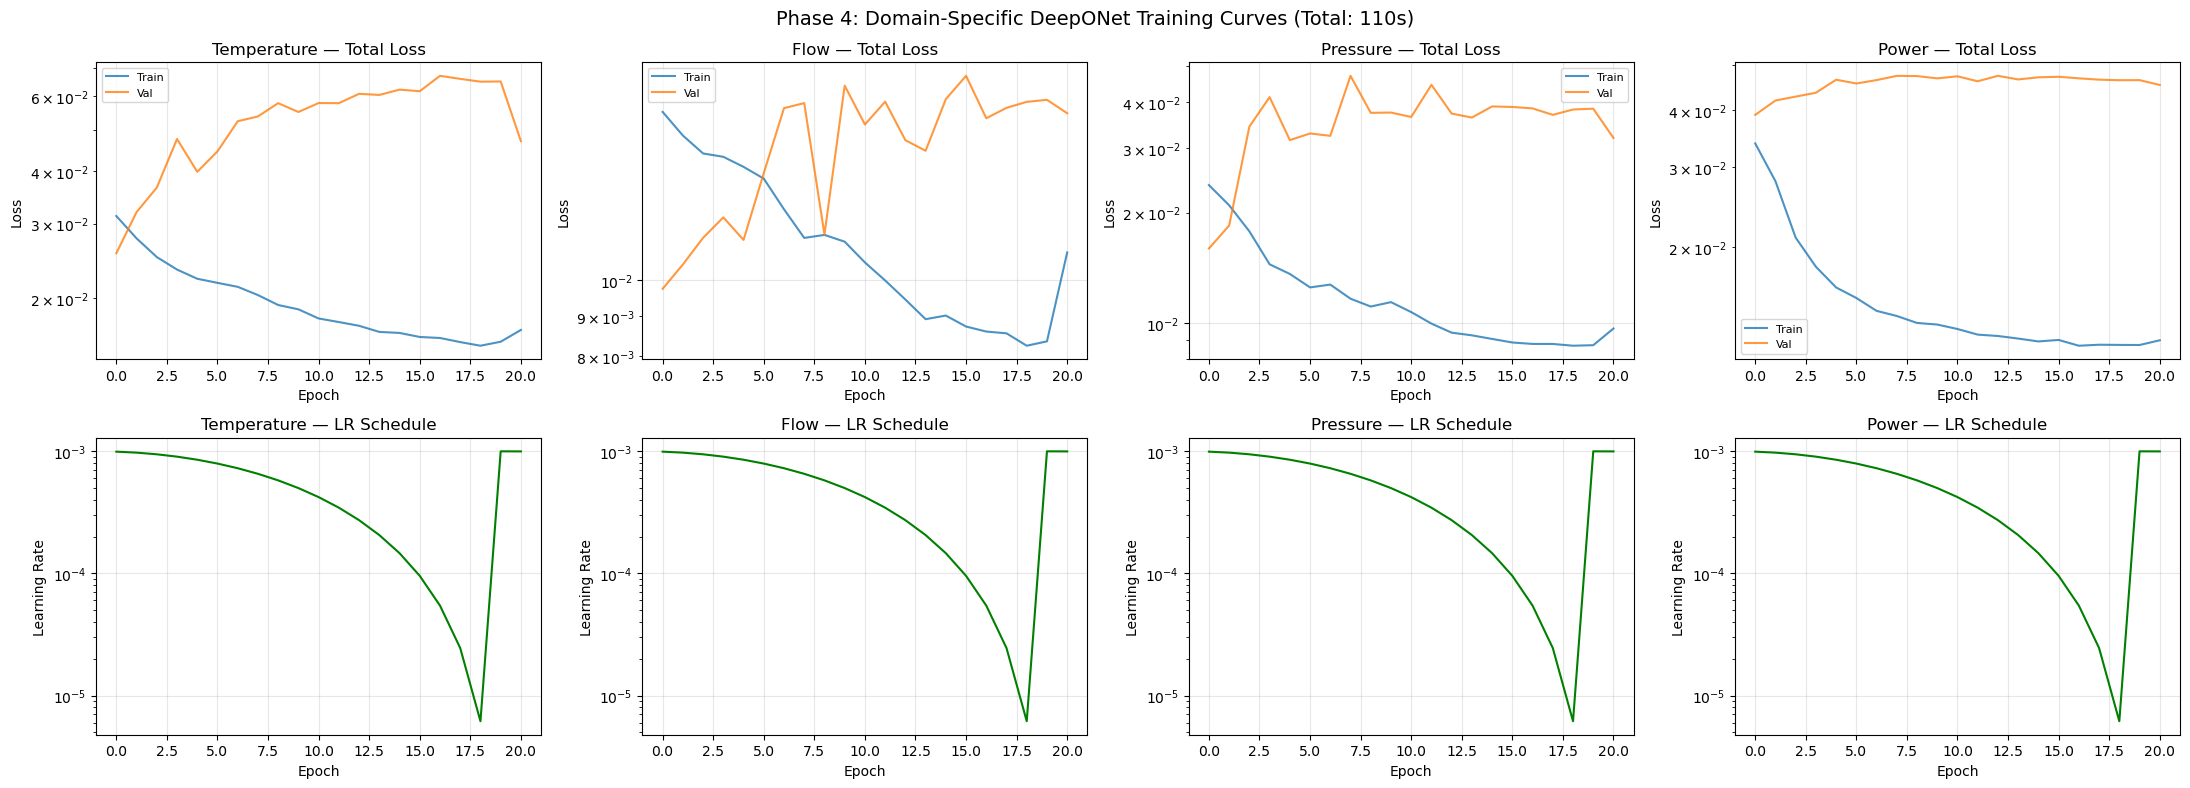

In [ ]:
#  Training Loss Curves

os.makedirs('phase_4_vis', exist_ok=True)

fig, axes = plt.subplots(2, 4, figsize=(22, 8))

domain_names = list(DOMAIN_CONFIGS.keys())
colors = {'temperature': 'tab:red', 'flow': 'tab:blue',
           'pressure': 'tab:green', 'power': 'tab:orange'}

for idx, domain_name in enumerate(domain_names):
    history = domain_histories[domain_name]

    # Total loss
    ax = axes[0, idx]
    ax.plot(history['train_total'], label='Train', linewidth=1.5, alpha=0.8)
    ax.plot(history['val_total'], label='Val', linewidth=1.5, alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{domain_name.capitalize()} — Total Loss')
    ax.legend(fontsize=8)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    # Learning rate
    ax = axes[1, idx]
    ax.plot(history['lr'], linewidth=1.5, color='green')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title(f'{domain_name.capitalize()} — LR Schedule')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Phase 4: Domain-Specific DeepONet Training Curves '
    f'(Total: {total_time:.0f}s)',
    fontsize=14)
plt.tight_layout()
plt.savefig('phase_4_vis/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

### Performance Metrics (from Chapter 3)

**Primary Accuracy Measures:** MAE, RMSE, R², Variance Ratio, Correlation Coefficient

**Delta Prediction Metrics:** Delta Std Ratio, Cumulative Drift Error

**Comparison Metrics:** Persistence R², Skill Score, Beats Persistence flag

**Phase 4–specific:** Per-domain performance, primary vs secondary loop dichotomy

**Computational Performance:** Training time, epochs, model parameters, inference time

In [ ]:
#  Collect Test Predictions for All Domains

print("Collecting test predictions for all domains...")

domain_predictions = {}
inference_times = {}

for domain_name, cfg in DOMAIN_CONFIGS.items():
    model = domain_models[domain_name]
    test_loader = domain_loaders[domain_name]['test']
    cols = domain_columns[domain_name]
    norms = domain_normalizers[domain_name]
    criterion = DomainLoss(cfg)

    inference_start = time.time()
    _, raw_preds = validate(model, test_loader, criterion, DEVICE)
    inference_time = time.time() - inference_start
    inference_times[domain_name] = inference_time

    # Convert normalized delta predictions to absolute
    pred_absolute = norms['domain'].inverse_transform(
        raw_preds['pred_normalized'],
        raw_preds['last_output'],
        cols['output_cols'])

    target_absolute = raw_preds['future_output']

    domain_predictions[domain_name] = {
        'pred_absolute': pred_absolute,
        'target_absolute': target_absolute,
        'pred_normalized': raw_preds['pred_normalized'],
        'target_normalized': raw_preds['target_normalized'],
        'last_output': raw_preds['last_output'],
    }
    if 'alpha' in raw_preds:
        domain_predictions[domain_name]['alpha'] = raw_preds['alpha']

    n_samples = pred_absolute.shape[0]
    print(f"  {domain_name}: shape={pred_absolute.shape}, "
          f"inference={inference_time:.2f}s ({inference_time/n_samples*1000:.2f} ms/sample)")

print("\nPredictions collected for all domains.")

  temperature: shape=(171, 4, 1028), inference=0.64s (3.74 ms/sample)
  flow: shape=(151, 4, 514), inference=0.54s (3.59 ms/sample)
  pressure: shape=(171, 4, 1028), inference=0.65s (3.82 ms/sample)
  power: shape=(171, 4, 257), inference=0.50s (2.91 ms/sample)

Predictions collected for all domains.


In [ ]:
#  Compute Comprehensive Metrics for All Domains

def compute_domain_metrics(
    domain_name: str,
    predictions_dict: Dict,
    column_info: Dict,
    output_cols: List[str],
    config,
) -> pd.DataFrame:
    """Compute per-output metrics matching Chapter 3 evaluation criteria."""
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_out = predictions_dict['last_output']
    K = config.PREDICTION_STEPS

    results = []
    for i, col in enumerate(output_cols):
        p = pred[:, :, i].flatten()
        t = target[:, :, i].flatten()

        # Primary accuracy measures
        mae = np.mean(np.abs(p - t))
        rmse = np.sqrt(np.mean((p - t) ** 2))

        ss_res = np.sum((t - p) ** 2)
        ss_tot = np.sum((t - t.mean()) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-10)

        var_pred = np.var(p)
        var_true = np.var(t)
        variance_ratio = var_pred / (var_true + 1e-10)

        if np.std(p) > 1e-10 and np.std(t) > 1e-10:
            correlation = np.corrcoef(p, t)[0, 1]
        else:
            correlation = 0.0

        # Delta prediction metrics
        pred_norm = predictions_dict['pred_normalized'][:, :, i].flatten()
        targ_norm = predictions_dict['target_normalized'][:, :, i].flatten()
        delta_std_ratio = np.std(pred_norm) / (np.std(targ_norm) + 1e-10)

        cumulative_drift = 0.0
        if K > 1:
            cumulative_drift = np.mean(np.abs(
                pred[:, -1, i] - target[:, -1, i])) - \
                np.mean(np.abs(pred[:, 0, i] - target[:, 0, i]))

        # Persistence baseline
        last_val = last_out[:, i]
        persistence = np.repeat(last_val[:, np.newaxis], K, axis=1).flatten()
        ss_res_pers = np.sum((t - persistence) ** 2)
        r2_pers = 1 - ss_res_pers / (ss_tot + 1e-10)
        skill_score = (r2 - r2_pers) / (1 - r2_pers + 1e-10)

        # Column metadata
        cdu_id = column_info['col_to_cdu'].get(col, 'Unknown')
        output_type = column_info['col_to_type'].get(col, 'Unknown')
        is_primary = col in column_info['primary_cols']

        results.append({
            'Output': col,
            'Domain': domain_name,
            'CDU': cdu_id,
            'Type': output_type,
            'Category': 'Primary' if is_primary else ('Secondary' if col in column_info['secondary_cols'] else 'Single'),
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            'Variance_Ratio': variance_ratio,
            'Correlation': correlation,
            'Delta_Std_Ratio': delta_std_ratio,
            'Cumulative_Drift': cumulative_drift,
            'Persistence_R²': r2_pers,
            'Beats_Persistence': r2 > r2_pers,
            'Skill_Score': skill_score,
        })

    return pd.DataFrame(results)


# Compute metrics for all domains
all_metrics_dfs = []
for domain_name in DOMAIN_CONFIGS:
    cols = domain_columns[domain_name]
    cfg = DOMAIN_CONFIGS[domain_name]
    preds = domain_predictions[domain_name]

    metrics = compute_domain_metrics(
        domain_name, preds, cols['column_info'], cols['output_cols'], cfg)
    all_metrics_dfs.append(metrics)

# Combined metrics DataFrame
metrics_df = pd.concat(all_metrics_dfs, ignore_index=True)
print(f"Metrics computed for {len(metrics_df)} outputs across {len(DOMAIN_CONFIGS)} domains.")

Metrics computed for 2827 outputs across 4 domains.


In [ ]:
#  Results Summary

print("\n" + "=" * 70)
print("RESULTS SUMMARY — Phase 4: Domain-Specific DeepONet Models")
print("=" * 70)

# Overall
print(f"\n--- All {len(metrics_df)} Outputs ---")
print(f"  Mean R²:           {metrics_df['R²'].mean():.4f}")
print(f"  Median R²:         {metrics_df['R²'].median():.4f}")
print(f"  Min R²:            {metrics_df['R²'].min():.4f}")
print(f"  Max R²:            {metrics_df['R²'].max():.4f}")
print(f"  Std R²:            {metrics_df['R²'].std():.4f}")
print(f"  Beats Persistence: {metrics_df['Beats_Persistence'].sum()}/{len(metrics_df)} "
      f"({metrics_df['Beats_Persistence'].mean():.1%})")
print(f"  Mean Skill Score:  {metrics_df['Skill_Score'].mean():.4f}")

# Per domain
print(f"\n--- Per Domain ---")
for domain_name in DOMAIN_CONFIGS:
    dom_df = metrics_df[metrics_df['Domain'] == domain_name]
    n = len(dom_df)
    r2_mean = dom_df['R²'].mean()
    status = 'Excellent' if r2_mean > 0.9 else ('Good' if r2_mean > 0.7 else ('Fair' if r2_mean > 0.3 else 'Poor'))
    print(f"\n  {domain_name.upper()} ({n} outputs, {status}):")
    print(f"    Mean R²:         {r2_mean:.4f} ± {dom_df['R²'].std():.4f}")
    print(f"    Median R²:       {dom_df['R²'].median():.4f}")
    print(f"    Min R²:          {dom_df['R²'].min():.4f}")
    print(f"    Variance Ratio:  {dom_df['Variance_Ratio'].mean():.4f}")
    print(f"    Beats Persist:   {dom_df['Beats_Persistence'].sum()}/{n} "
          f"({dom_df['Beats_Persistence'].mean():.1%})")
    print(f"    Mean Skill:      {dom_df['Skill_Score'].mean():.4f}")

# Per output type
print(f"\n--- Per Output Type ---")
type_summary = metrics_df.groupby('Type').agg({
    'R²': ['mean', 'median', 'min', 'max', 'count'],
    'RMSE': 'mean',
    'MAE': 'mean',
    'Variance_Ratio': 'mean',
    'Correlation': 'mean',
    'Beats_Persistence': 'mean',
}).round(4)
print(type_summary.to_string())

# Primary vs Secondary
print(f"\n--- Primary vs Secondary Loop ---")
for cat in ['Primary', 'Secondary', 'Single']:
    cat_df = metrics_df[metrics_df['Category'] == cat]
    if len(cat_df) > 0:
        print(f"  {cat} ({len(cat_df)} outputs): "
              f"Mean R²={cat_df['R²'].mean():.4f}, "
              f"Beats Persist={cat_df['Beats_Persistence'].sum()}/{len(cat_df)}")

# R² distribution
print(f"\n--- R² Distribution ---")
for threshold, label in [(0.99, '≥ 0.99'), (0.95, '≥ 0.95'), (0.90, '≥ 0.90'),
                          (0.80, '≥ 0.80'), (0.50, '≥ 0.50'), (0.0, '≥ 0.00')]:
    count = (metrics_df['R²'] >= threshold).sum()
    print(f"  R² {label}: {count}/{len(metrics_df)} ({count/len(metrics_df):.1%})")
count_neg = (metrics_df['R²'] < 0).sum()
print(f"  R² < 0.00: {count_neg}/{len(metrics_df)} ({count_neg/len(metrics_df):.1%})")

# Computational summary
total_params_all = sum(p['total'] for p in domain_params.values())
total_inference = sum(inference_times.values())
total_train = sum(domain_train_times.values())
print(f"\n--- Computational Performance ---")
print(f"  Total Parameters:  {total_params_all:,}")
for dn in DOMAIN_CONFIGS:
    print(f"    {dn:12s}: {domain_params[dn]['total']:,}")
print(f"  Total Train Time:  {total_train:.0f}s ({total_train/60:.1f} min)")
print(f"  Total Inference:   {total_inference:.2f}s")


RESULTS SUMMARY — Phase 4: Domain-Specific DeepONet Models

--- All 2827 Outputs ---
  Mean R²:           0.8814
  Median R²:         0.9512
  Min R²:            -0.1466
  Max R²:            0.9969
  Std R²:            0.1474
  Beats Persistence: 1999/2827 (70.7%)
  Mean Skill Score:  0.0066

--- Per Domain ---

  TEMPERATURE (1028 outputs, Excellent):
    Mean R²:         0.9514 ± 0.0309
    Median R²:       0.9623
    Min R²:          0.7695
    Variance Ratio:  0.9956
    Beats Persist:   674/1028 (65.6%)
    Mean Skill:      -0.0059

  FLOW (514 outputs, Good):
    Mean R²:         0.7591 ± 0.2092
    Median R²:       0.8878
    Min R²:          -0.1466
    Variance Ratio:  1.0242
    Beats Persist:   353/514 (68.7%)
    Mean Skill:      0.0041

  PRESSURE (1028 outputs, Good):
    Mean R²:         0.8506 ± 0.1469
    Median R²:       0.9566
    Min R²:          0.1673
    Variance Ratio:  1.0058
    Beats Persist:   866/1028 (84.2%)
    Mean Skill:      0.0325

  POWER (257 outpu

## Evaluation Metric Visualizations

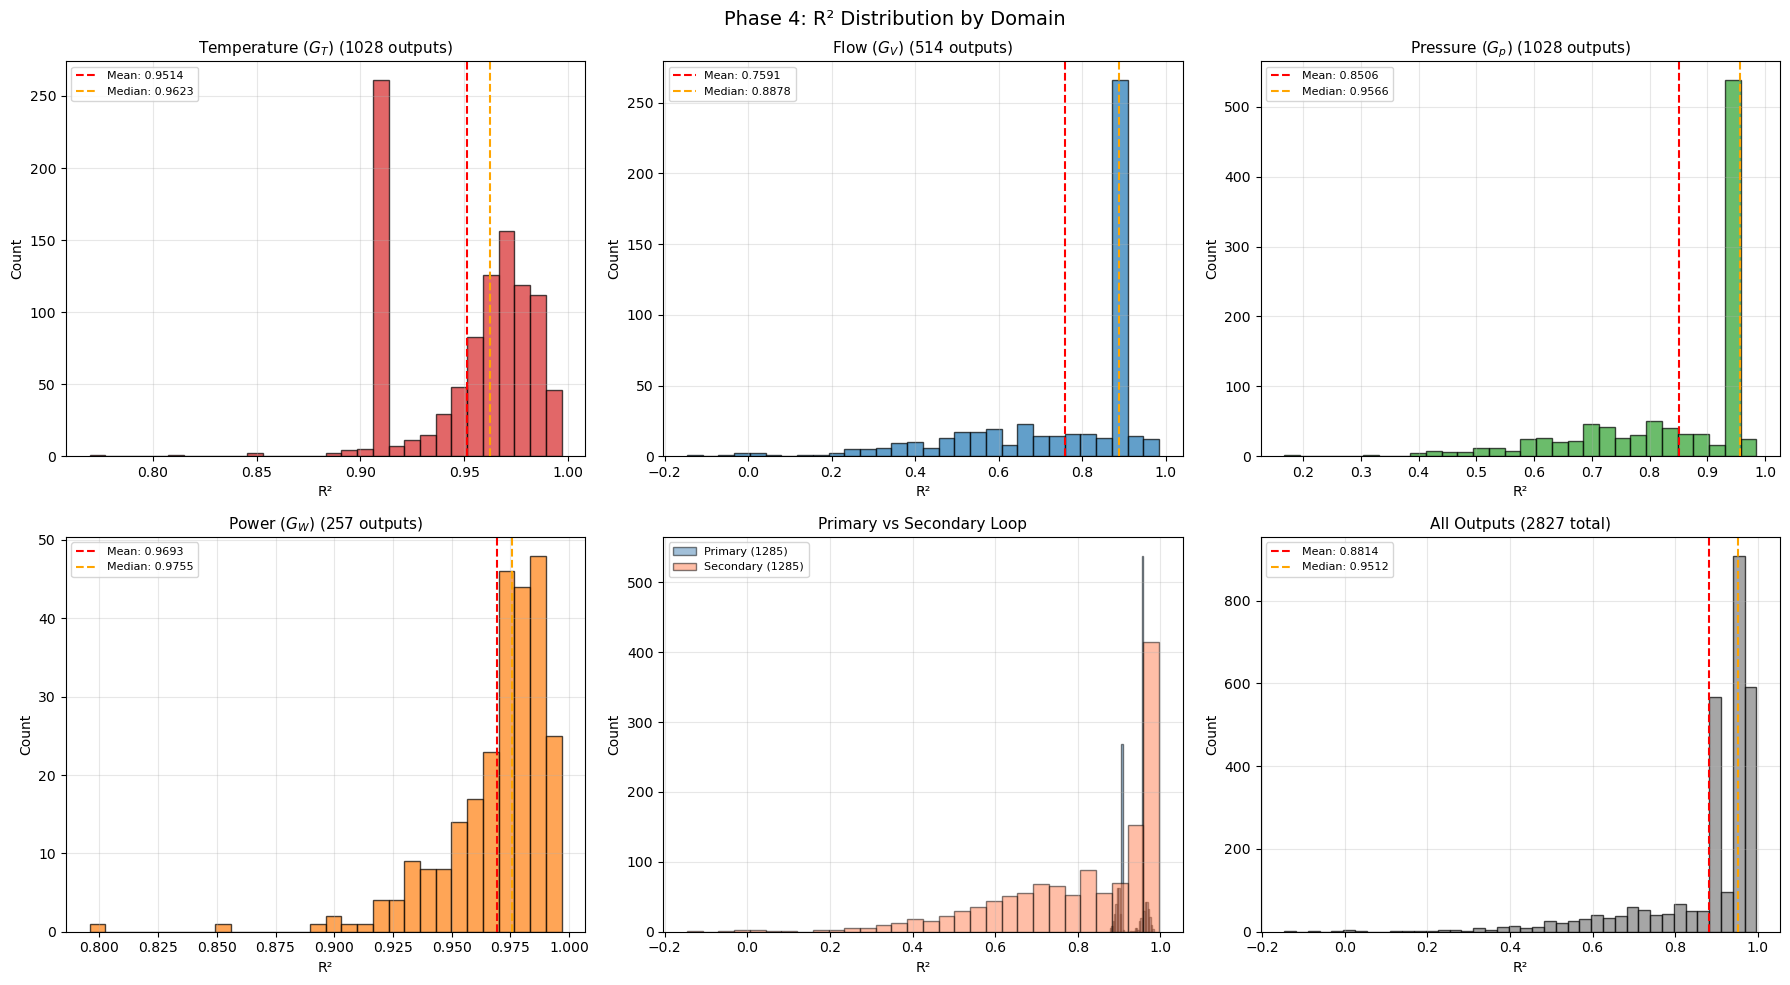

In [ ]:
#  Visualization 1 — R² Distribution by Domain

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

domain_labels = {
    'temperature': 'Temperature ($G_T$)',
    'flow': 'Flow ($G_V$)',
    'pressure': 'Pressure ($G_p$)',
    'power': 'Power ($G_W$)',
}
domain_colors = {
    'temperature': 'tab:red',
    'flow': 'tab:blue',
    'pressure': 'tab:green',
    'power': 'tab:orange',
}

for idx, domain_name in enumerate(DOMAIN_CONFIGS):
    ax = axes[idx]
    dom_data = metrics_df[metrics_df['Domain'] == domain_name]['R²']
    if len(dom_data) == 0:
        ax.set_visible(False)
        continue
    ax.hist(dom_data, bins=min(30, len(dom_data)), alpha=0.7,
            edgecolor='black', color=domain_colors[domain_name])
    ax.axvline(dom_data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {dom_data.mean():.4f}')
    ax.axvline(dom_data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {dom_data.median():.4f}')
    ax.set_title(f'{domain_labels[domain_name]} ({len(dom_data)} outputs)', fontsize=11)
    ax.set_xlabel('R²')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Primary vs Secondary
ax = axes[4]
for cat, color in [('Primary', 'steelblue'), ('Secondary', 'coral')]:
    cat_data = metrics_df[metrics_df['Category'] == cat]['R²']
    if len(cat_data) > 0:
        ax.hist(cat_data, bins=30, alpha=0.5, edgecolor='black',
                color=color, label=f'{cat} ({len(cat_data)})')
ax.set_title('Primary vs Secondary Loop', fontsize=11)
ax.set_xlabel('R²')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# All outputs
ax = axes[5]
ax.hist(metrics_df['R²'], bins=40, alpha=0.7, edgecolor='black', color='gray')
ax.axvline(metrics_df['R²'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {metrics_df["R²"].mean():.4f}')
ax.axvline(metrics_df['R²'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {metrics_df["R²"].median():.4f}')
ax.set_title(f'All Outputs ({len(metrics_df)} total)', fontsize=11)
ax.set_xlabel('R²')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Phase 4: R² Distribution by Domain', fontsize=14)
plt.tight_layout()
plt.savefig('phase_4_vis/r2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

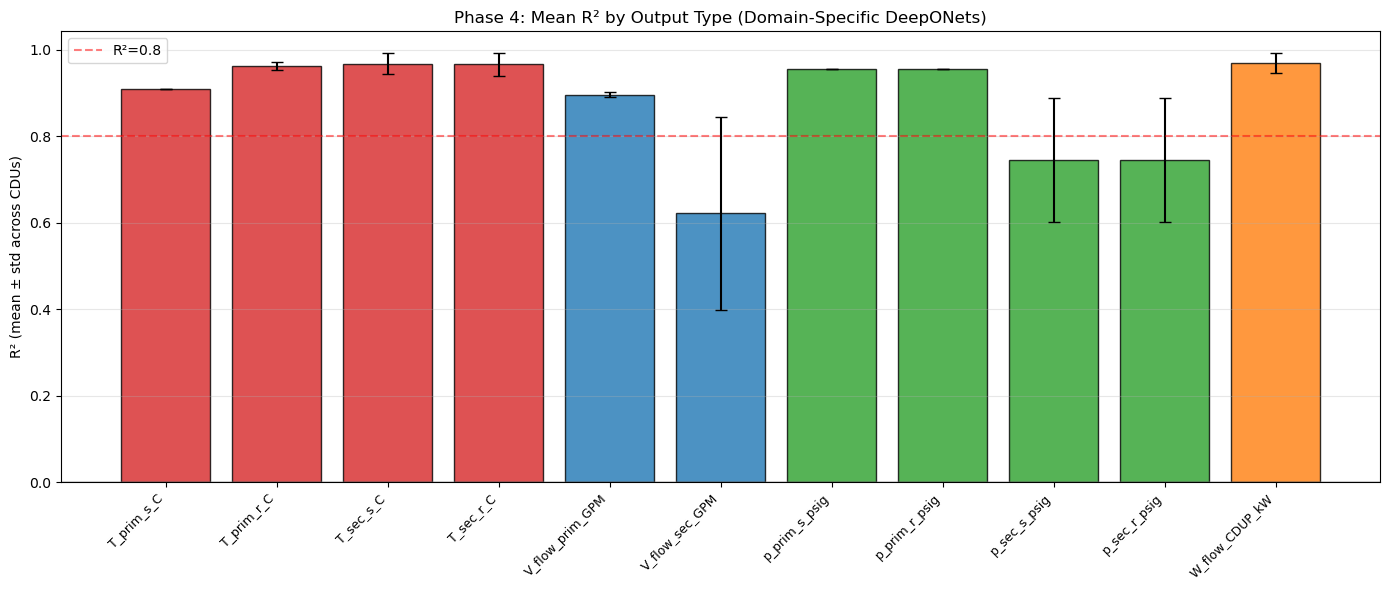

In [ ]:
#  Visualization 2 — Per-Output-Type R² Bar Chart

output_types = metrics_df['Type'].unique()
type_means = metrics_df.groupby('Type')['R²'].agg(['mean', 'std']).reindex(output_types)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(output_types))
bars = ax.bar(x, type_means['mean'], yerr=type_means['std'], capsize=4,
              alpha=0.8, edgecolor='black')

# Color by domain
type_to_domain = {}
for _, row in metrics_df.drop_duplicates('Type').iterrows():
    type_to_domain[row['Type']] = row['Domain']

for i, otype in enumerate(output_types):
    bars[i].set_facecolor(domain_colors.get(type_to_domain.get(otype, ''), 'gray'))

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R² (mean ± std across CDUs)')
ax.set_title('Phase 4: Mean R² by Output Type (Domain-Specific DeepONets)')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='R²=0.8')
ax.axhline(y=0.0, color='gray', linestyle='-', alpha=0.3)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_4_vis/r2_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

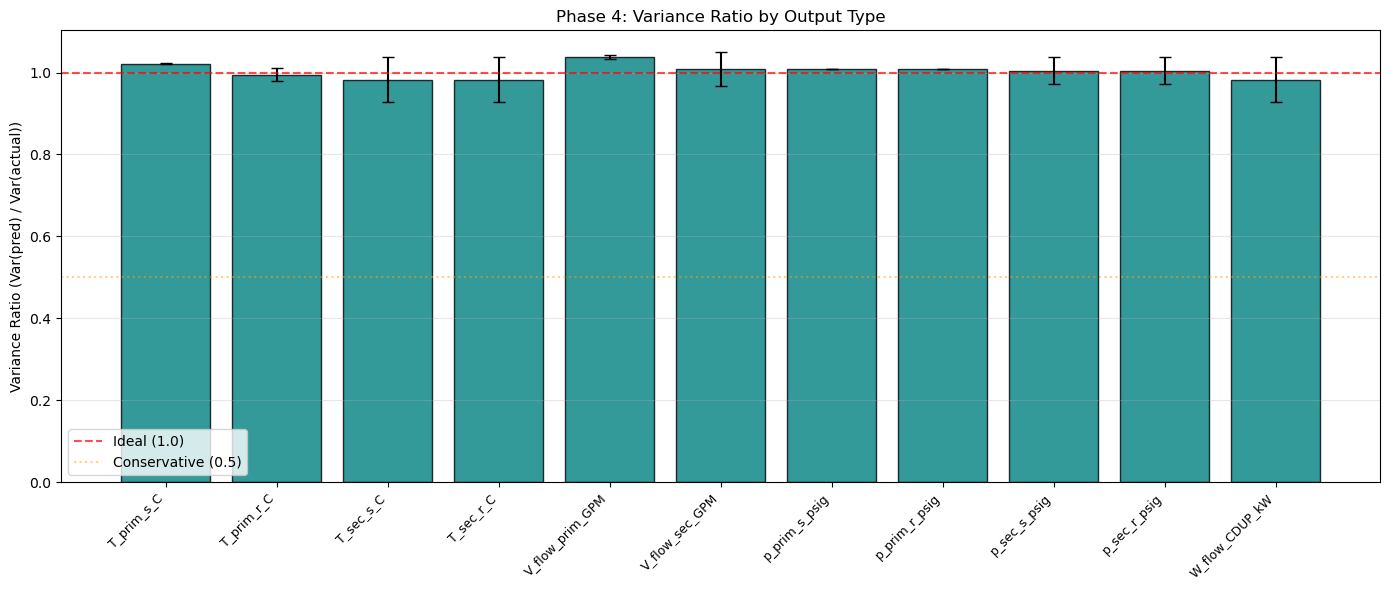

In [ ]:
#  Visualization 3 — Variance Ratio by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_var = metrics_df.groupby('Type')['Variance_Ratio'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_var['mean'], yerr=type_var['std'], capsize=4,
              color='teal', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Variance Ratio (Var(pred) / Var(actual))')
ax.set_title('Phase 4: Variance Ratio by Output Type')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Ideal (1.0)')
ax.axhline(y=0.5, color='orange', linestyle=':', alpha=0.5, label='Conservative (0.5)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_4_vis/variance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

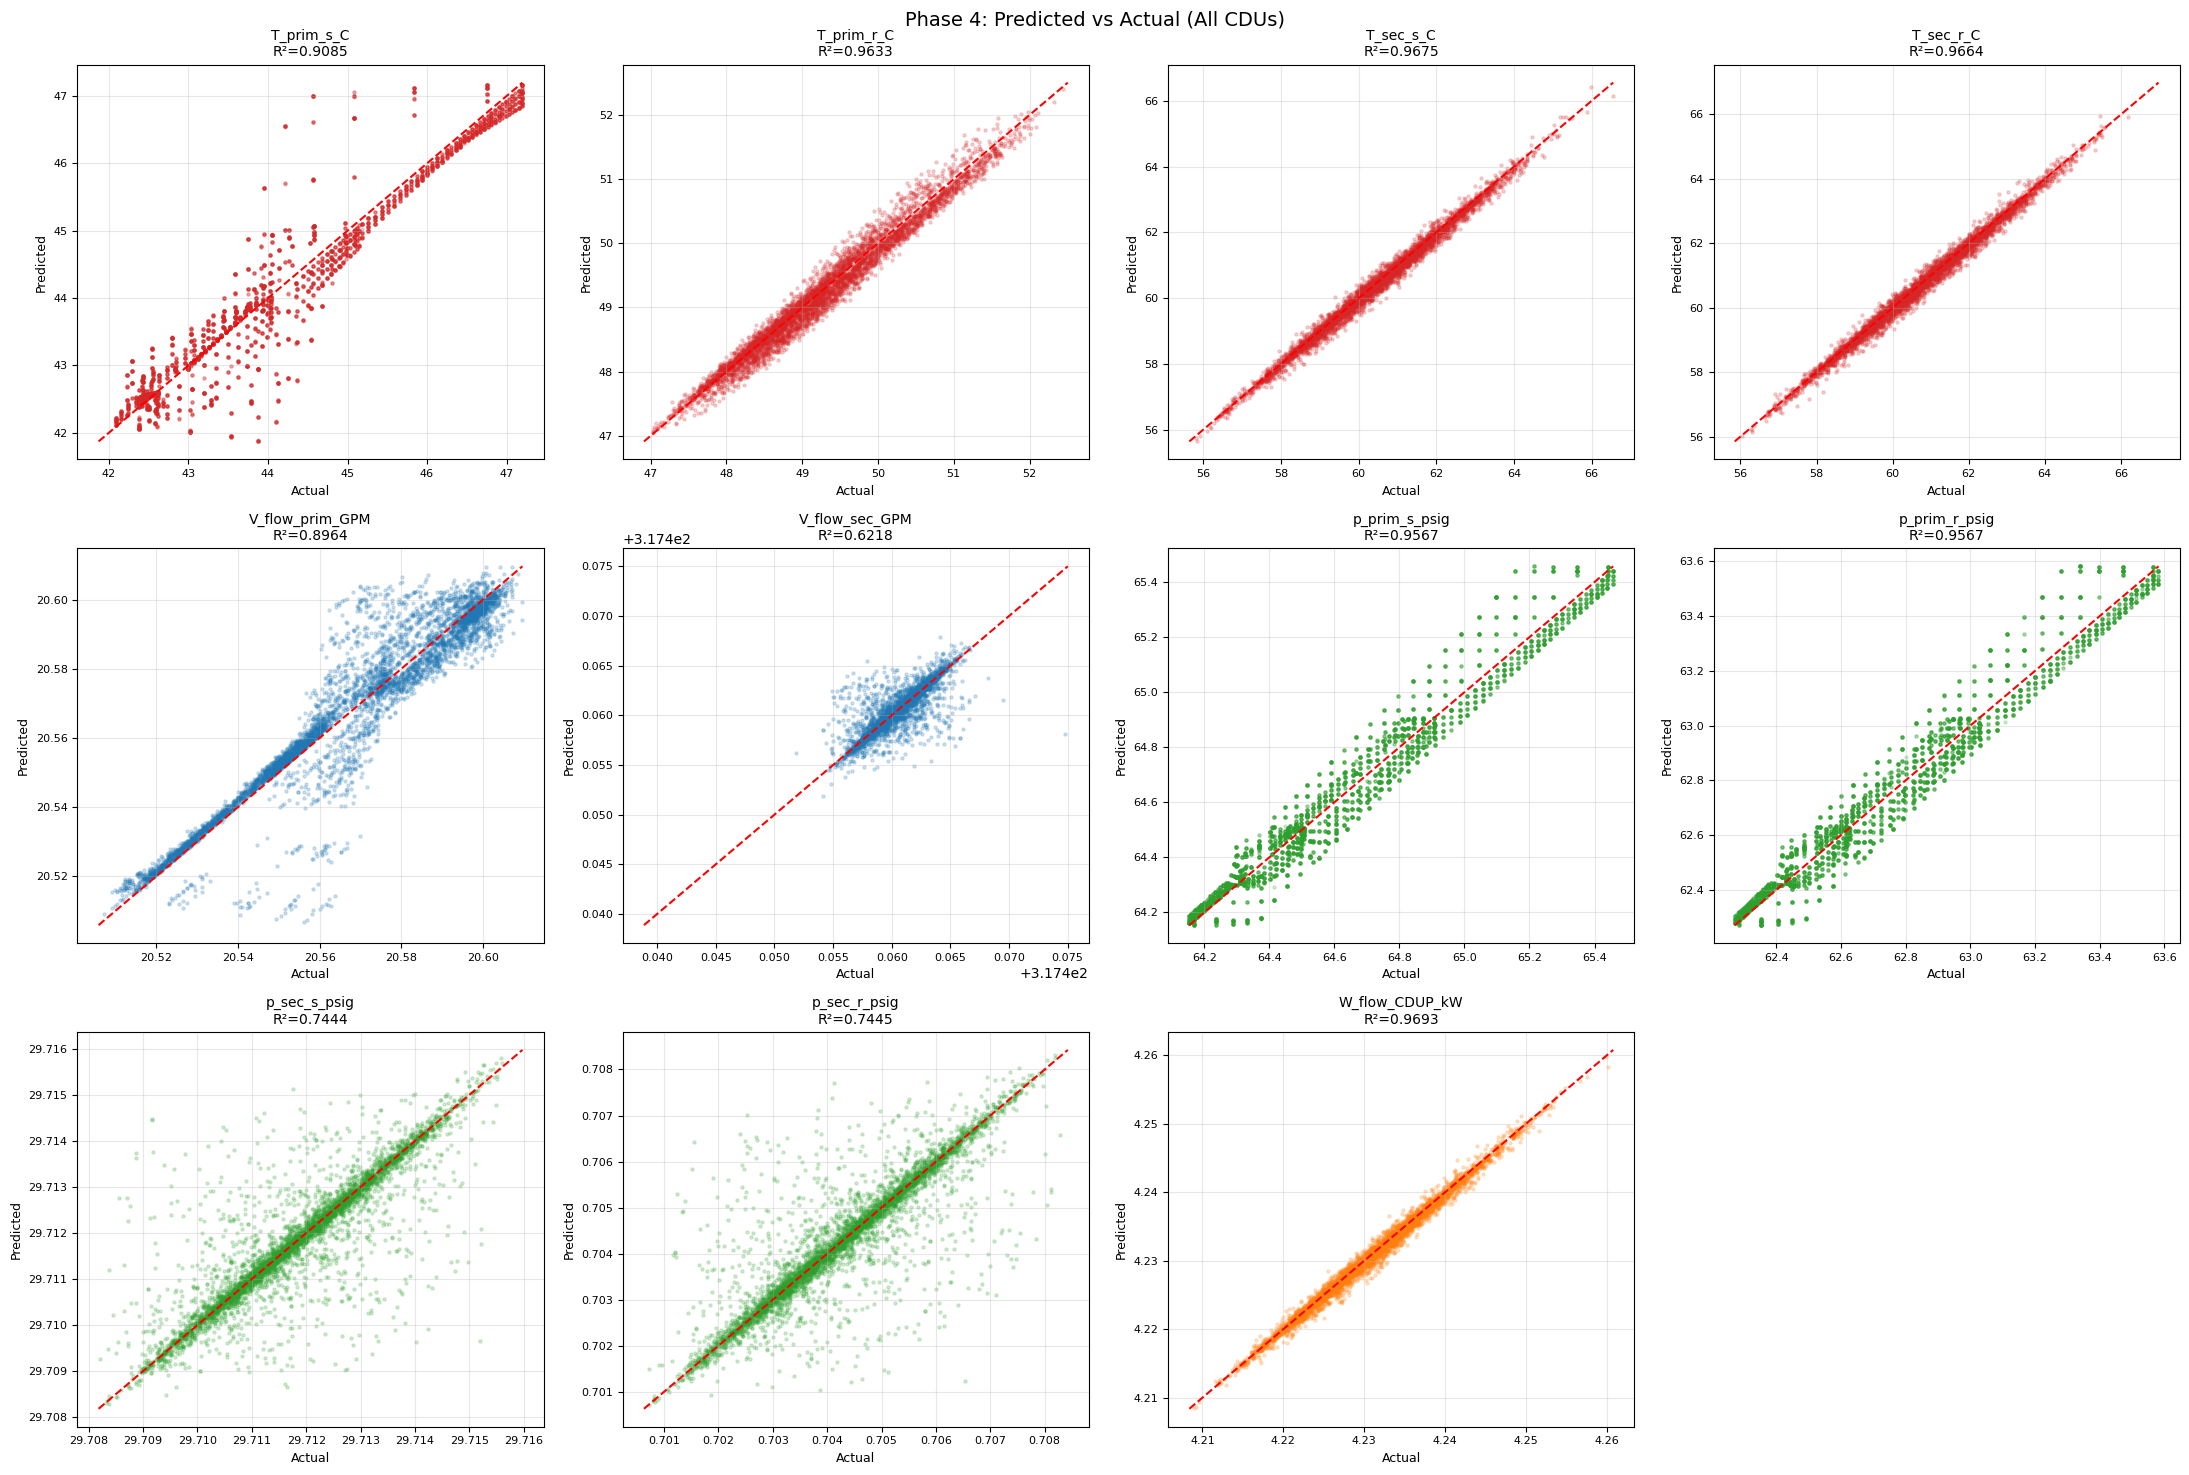

In [ ]:
#  Visualization 4 — Scatter Plots per Output Type

n_types = len(output_types)
n_cols_plot = min(4, n_types)
n_rows_plot = (n_types + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(5.5 * n_cols_plot, 5 * n_rows_plot))
if n_rows_plot == 1 and n_cols_plot == 1:
    axes = np.array([[axes]])
elif n_rows_plot == 1:
    axes = axes.reshape(1, -1)
elif n_cols_plot == 1:
    axes = axes.reshape(-1, 1)

for idx, output_type in enumerate(output_types):
    row, col_idx = divmod(idx, n_cols_plot)
    ax = axes[row, col_idx]

    type_df = metrics_df[metrics_df['Type'] == output_type]
    domain_name = type_df['Domain'].iloc[0]
    preds = domain_predictions[domain_name]
    cols = domain_columns[domain_name]

    all_pred, all_target = [], []
    for i, col in enumerate(cols['output_cols']):
        if cols['column_info']['col_to_type'].get(col) == output_type:
            all_pred.append(preds['pred_absolute'][:, :, i].flatten())
            all_target.append(preds['target_absolute'][:, :, i].flatten())

    if not all_pred:
        ax.set_visible(False)
        continue

    all_pred_arr = np.concatenate(all_pred)
    all_target_arr = np.concatenate(all_target)

    n_plot = min(5000, len(all_pred_arr))
    plot_idx = np.random.choice(len(all_pred_arr), n_plot, replace=False)

    ax.scatter(all_target_arr[plot_idx], all_pred_arr[plot_idx], alpha=0.2, s=5,
               c=domain_colors.get(domain_name, 'gray'))
    vmin = min(all_target_arr.min(), all_pred_arr.min())
    vmax = max(all_target_arr.max(), all_pred_arr.max())
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.5)

    r2_val = type_df['R²'].mean()
    ax.set_title(f'{output_type}\nR²={r2_val:.4f}', fontsize=10)
    ax.set_xlabel('Actual', fontsize=9)
    ax.set_ylabel('Predicted', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for idx in range(n_types, n_rows_plot * n_cols_plot):
    row, col_idx = divmod(idx, n_cols_plot)
    axes[row, col_idx].set_visible(False)

plt.suptitle('Phase 4: Predicted vs Actual (All CDUs)', fontsize=14)
plt.tight_layout()
plt.savefig('phase_4_vis/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

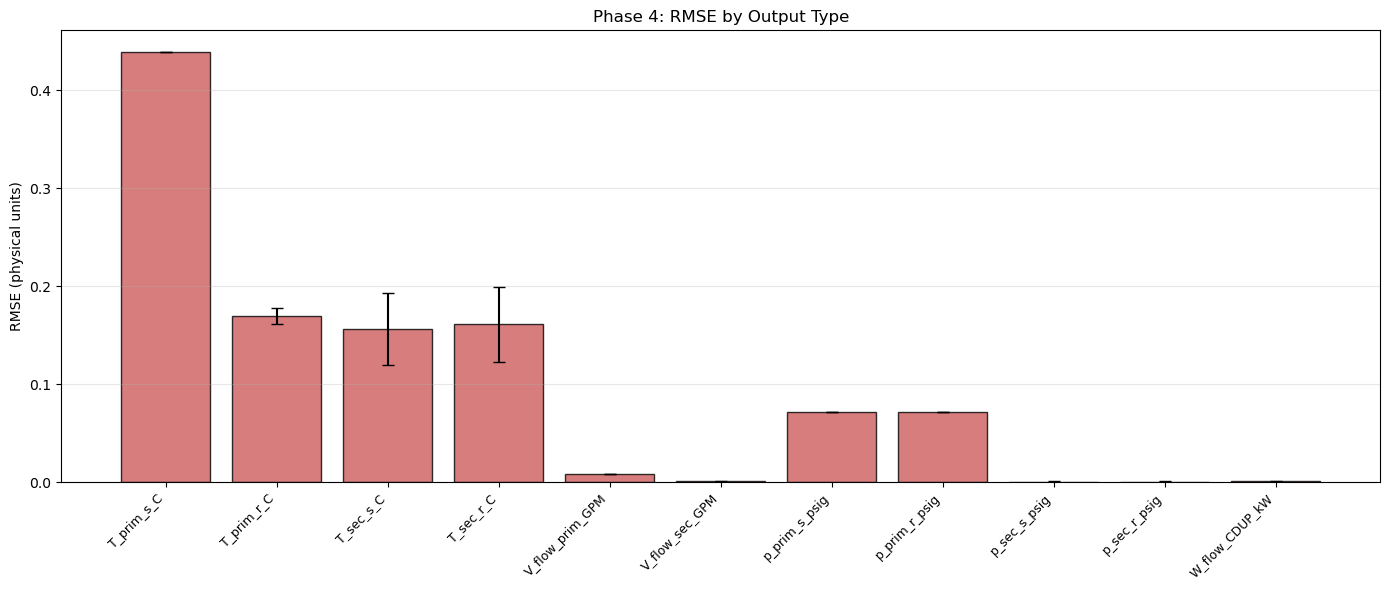

In [ ]:
#  Visualization 5 — RMSE by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_rmse = metrics_df.groupby('Type')['RMSE'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_rmse['mean'], yerr=type_rmse['std'], capsize=4,
              color='indianred', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('RMSE (physical units)')
ax.set_title('Phase 4: RMSE by Output Type')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_4_vis/rmse_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

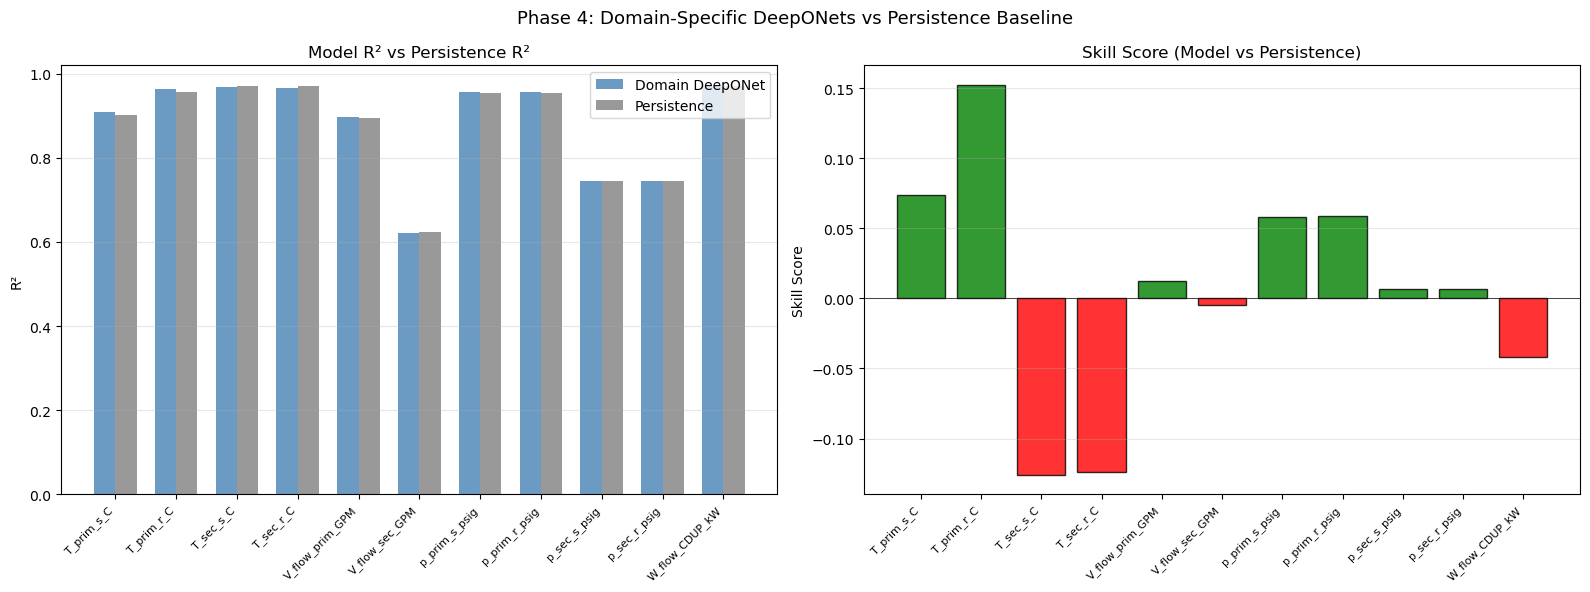

In [ ]:
#  Visualization 6 — Model vs Persistence Comparison

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_r2 = metrics_df.groupby('Type')['R²'].mean().reindex(output_types)
persist_r2 = metrics_df.groupby('Type')['Persistence_R²'].mean().reindex(output_types)

x = np.arange(len(output_types))
width = 0.35
axes[0].bar(x - width/2, model_r2, width, label='Domain DeepONet', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, persist_r2, width, label='Persistence', color='gray', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(output_types, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('R²')
axes[0].set_title('Model R² vs Persistence R²')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

skill = metrics_df.groupby('Type')['Skill_Score'].mean().reindex(output_types)
colors_skill = ['green' if s > 0 else 'red' for s in skill]
axes[1].bar(x, skill, color=colors_skill, alpha=0.8, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(output_types, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Skill Score')
axes[1].set_title('Skill Score (Model vs Persistence)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Phase 4: Domain-Specific DeepONets vs Persistence Baseline', fontsize=13)
plt.tight_layout()
plt.savefig('phase_4_vis/vs_persistence.png', dpi=150, bbox_inches='tight')
plt.show()

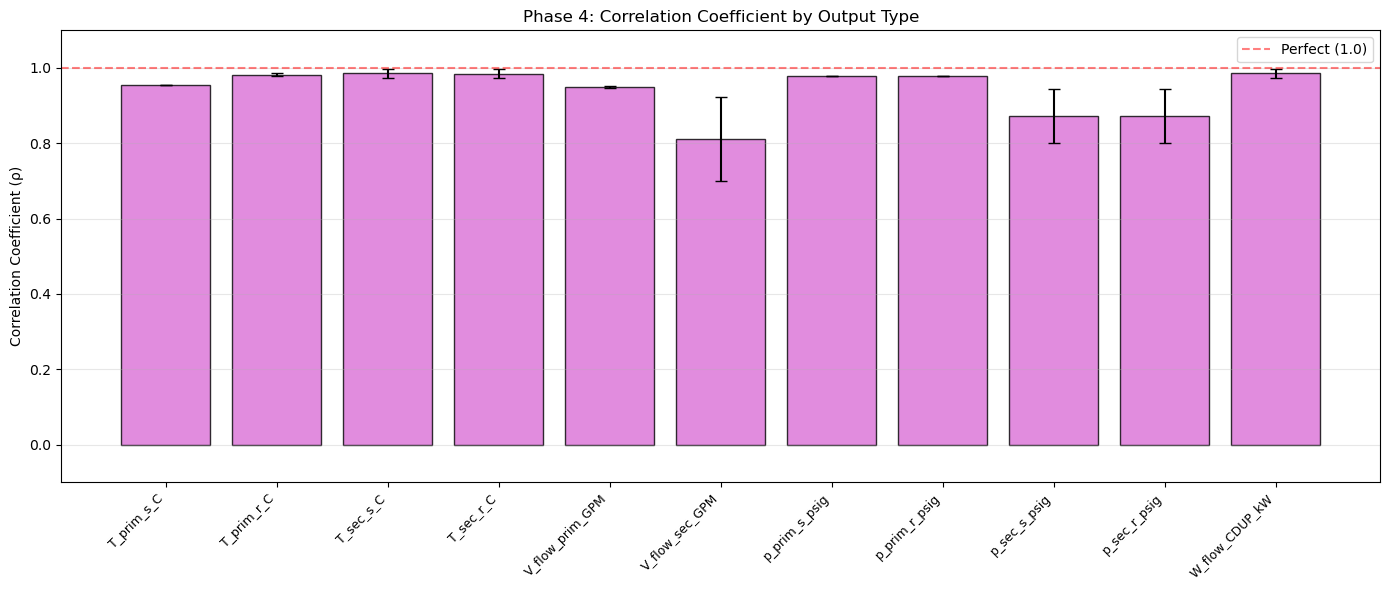

In [ ]:
#  Visualization 7 — Correlation Coefficient by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_corr = metrics_df.groupby('Type')['Correlation'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_corr['mean'], yerr=type_corr['std'], capsize=4,
              color='orchid', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Correlation Coefficient (ρ)')
ax.set_title('Phase 4: Correlation Coefficient by Output Type')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect (1.0)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.savefig('phase_4_vis/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

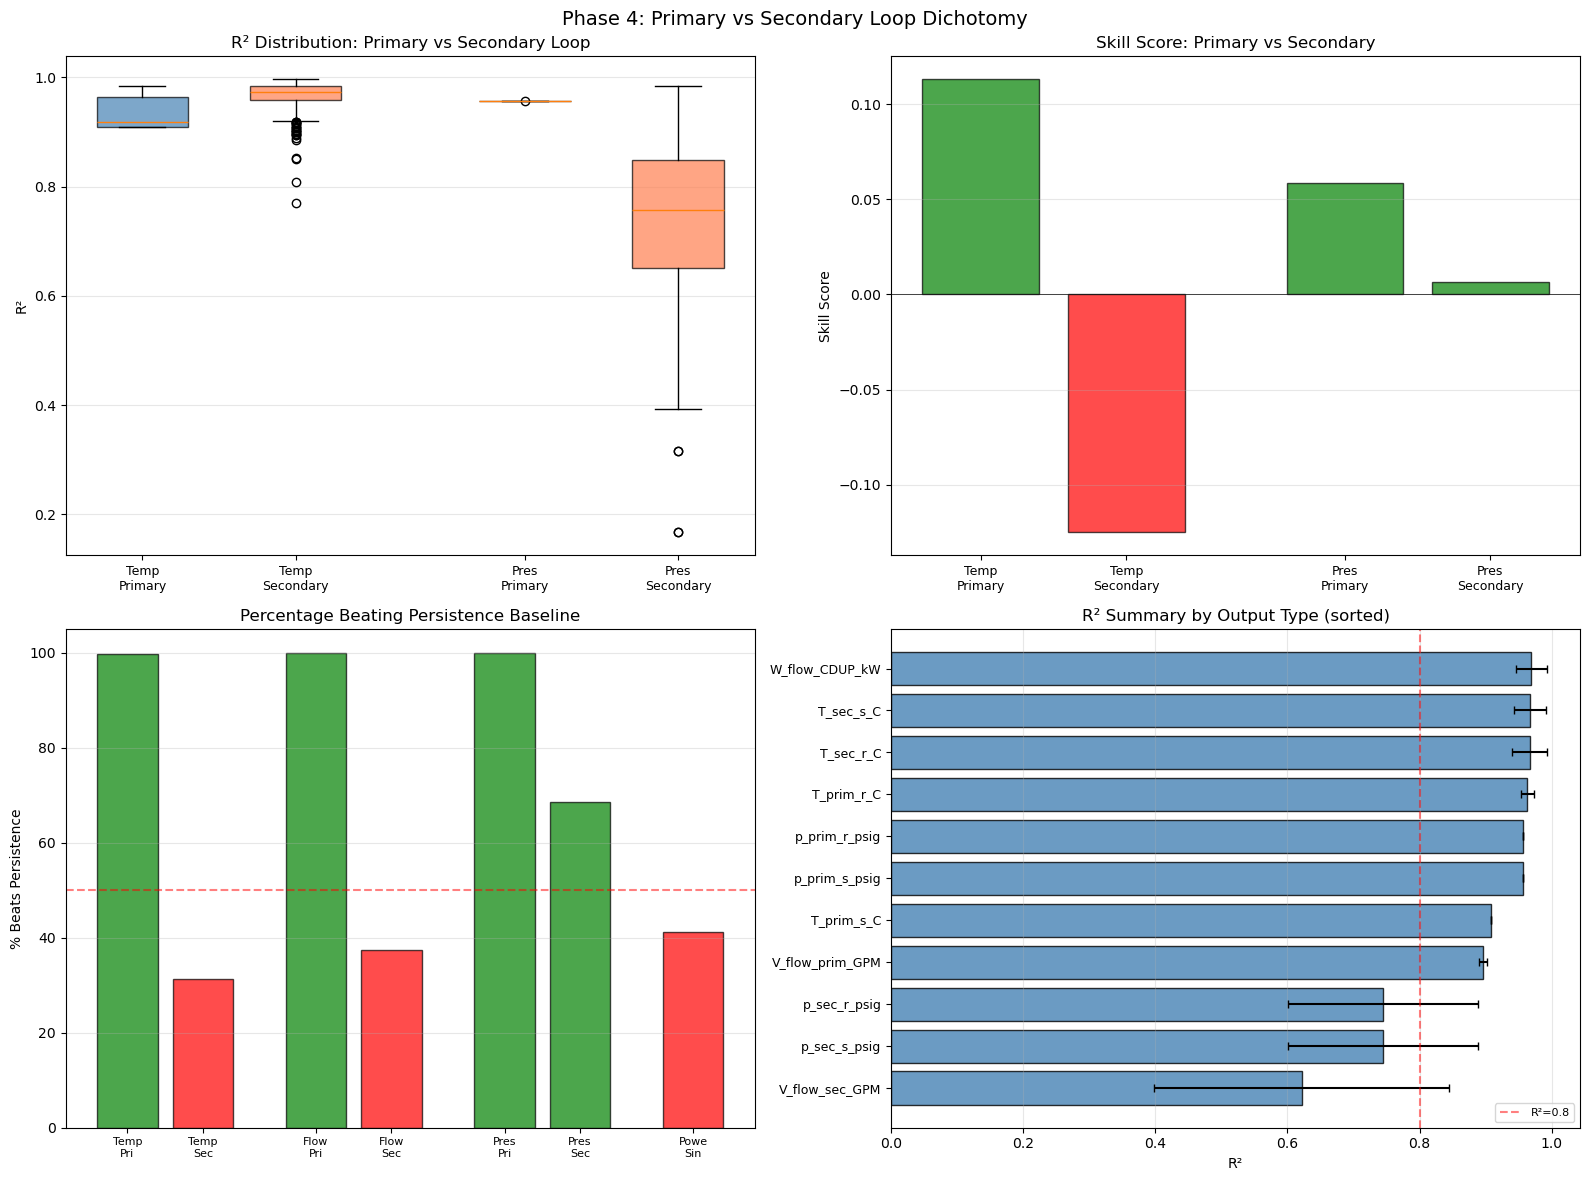

In [ ]:
#  Visualization 8 — Primary vs Secondary Loop Dichotomy

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² by Category (Primary vs Secondary) per domain
ax = axes[0, 0]
domains_with_dichotomy = ['temperature', 'pressure']
x_pos = 0
tick_labels, tick_positions = [], []
for domain_name in domains_with_dichotomy:
    dom_df = metrics_df[metrics_df['Domain'] == domain_name]
    for cat in ['Primary', 'Secondary']:
        cat_df = dom_df[dom_df['Category'] == cat]
        if len(cat_df) > 0:
            color = 'steelblue' if cat == 'Primary' else 'coral'
            bp = ax.boxplot(cat_df['R²'].values, positions=[x_pos], widths=0.6,
                           patch_artist=True,
                           boxprops=dict(facecolor=color, alpha=0.7))
            tick_labels.append(f'{domain_name[:4].capitalize()}\n{cat}')
            tick_positions.append(x_pos)
            x_pos += 1
    x_pos += 0.5

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylabel('R²')
ax.set_title('R² Distribution: Primary vs Secondary Loop')
ax.grid(True, alpha=0.3, axis='y')

# Skill Score by Category per domain
ax = axes[0, 1]
x_pos = 0
tick_labels, tick_positions = [], []
for domain_name in domains_with_dichotomy:
    dom_df = metrics_df[metrics_df['Domain'] == domain_name]
    for cat in ['Primary', 'Secondary']:
        cat_df = dom_df[dom_df['Category'] == cat]
        if len(cat_df) > 0:
            color = 'green' if cat_df['Skill_Score'].mean() > 0 else 'red'
            ax.bar(x_pos, cat_df['Skill_Score'].mean(), color=color, alpha=0.7,
                   edgecolor='black')
            tick_labels.append(f'{domain_name[:4].capitalize()}\n{cat}')
            tick_positions.append(x_pos)
            x_pos += 1
    x_pos += 0.5

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylabel('Skill Score')
ax.set_title('Skill Score: Primary vs Secondary')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Beats persistence per domain/category
ax = axes[1, 0]
x_pos = 0
tick_labels, tick_positions = [], []
for domain_name in DOMAIN_CONFIGS:
    dom_df = metrics_df[metrics_df['Domain'] == domain_name]
    categories = dom_df['Category'].unique()
    for cat in categories:
        cat_df = dom_df[dom_df['Category'] == cat]
        if len(cat_df) > 0:
            pct = cat_df['Beats_Persistence'].mean() * 100
            color = 'green' if pct > 50 else 'red'
            ax.bar(x_pos, pct, color=color, alpha=0.7, edgecolor='black')
            tick_labels.append(f'{domain_name[:4].capitalize()}\n{cat[:3]}')
            tick_positions.append(x_pos)
            x_pos += 1
    x_pos += 0.5

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_ylabel('% Beats Persistence')
ax.set_title('Percentage Beating Persistence Baseline')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# R² heatmap by output type
ax = axes[1, 1]
heatmap_data = metrics_df.groupby('Type')['R²'].agg(['mean', 'std', 'min', 'max'])
heatmap_data = heatmap_data.sort_values('mean', ascending=True)

y_pos = np.arange(len(heatmap_data))
ax.barh(y_pos, heatmap_data['mean'], xerr=heatmap_data['std'],
        capsize=3, color='steelblue', alpha=0.8, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_xlabel('R²')
ax.set_title('R² Summary by Output Type (sorted)')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='R²=0.8')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Phase 4: Primary vs Secondary Loop Dichotomy', fontsize=14)
plt.tight_layout()
plt.savefig('phase_4_vis/loop_dichotomy.png', dpi=150, bbox_inches='tight')
plt.show()

## Time-Series Predictions (300-second sample)

For each domain and output type, a 300-second window comparing:
- **Actual** (ground truth) values
- **Model prediction** (Domain-Specific DeepONet)
- **Persistence baseline** (last observed value)

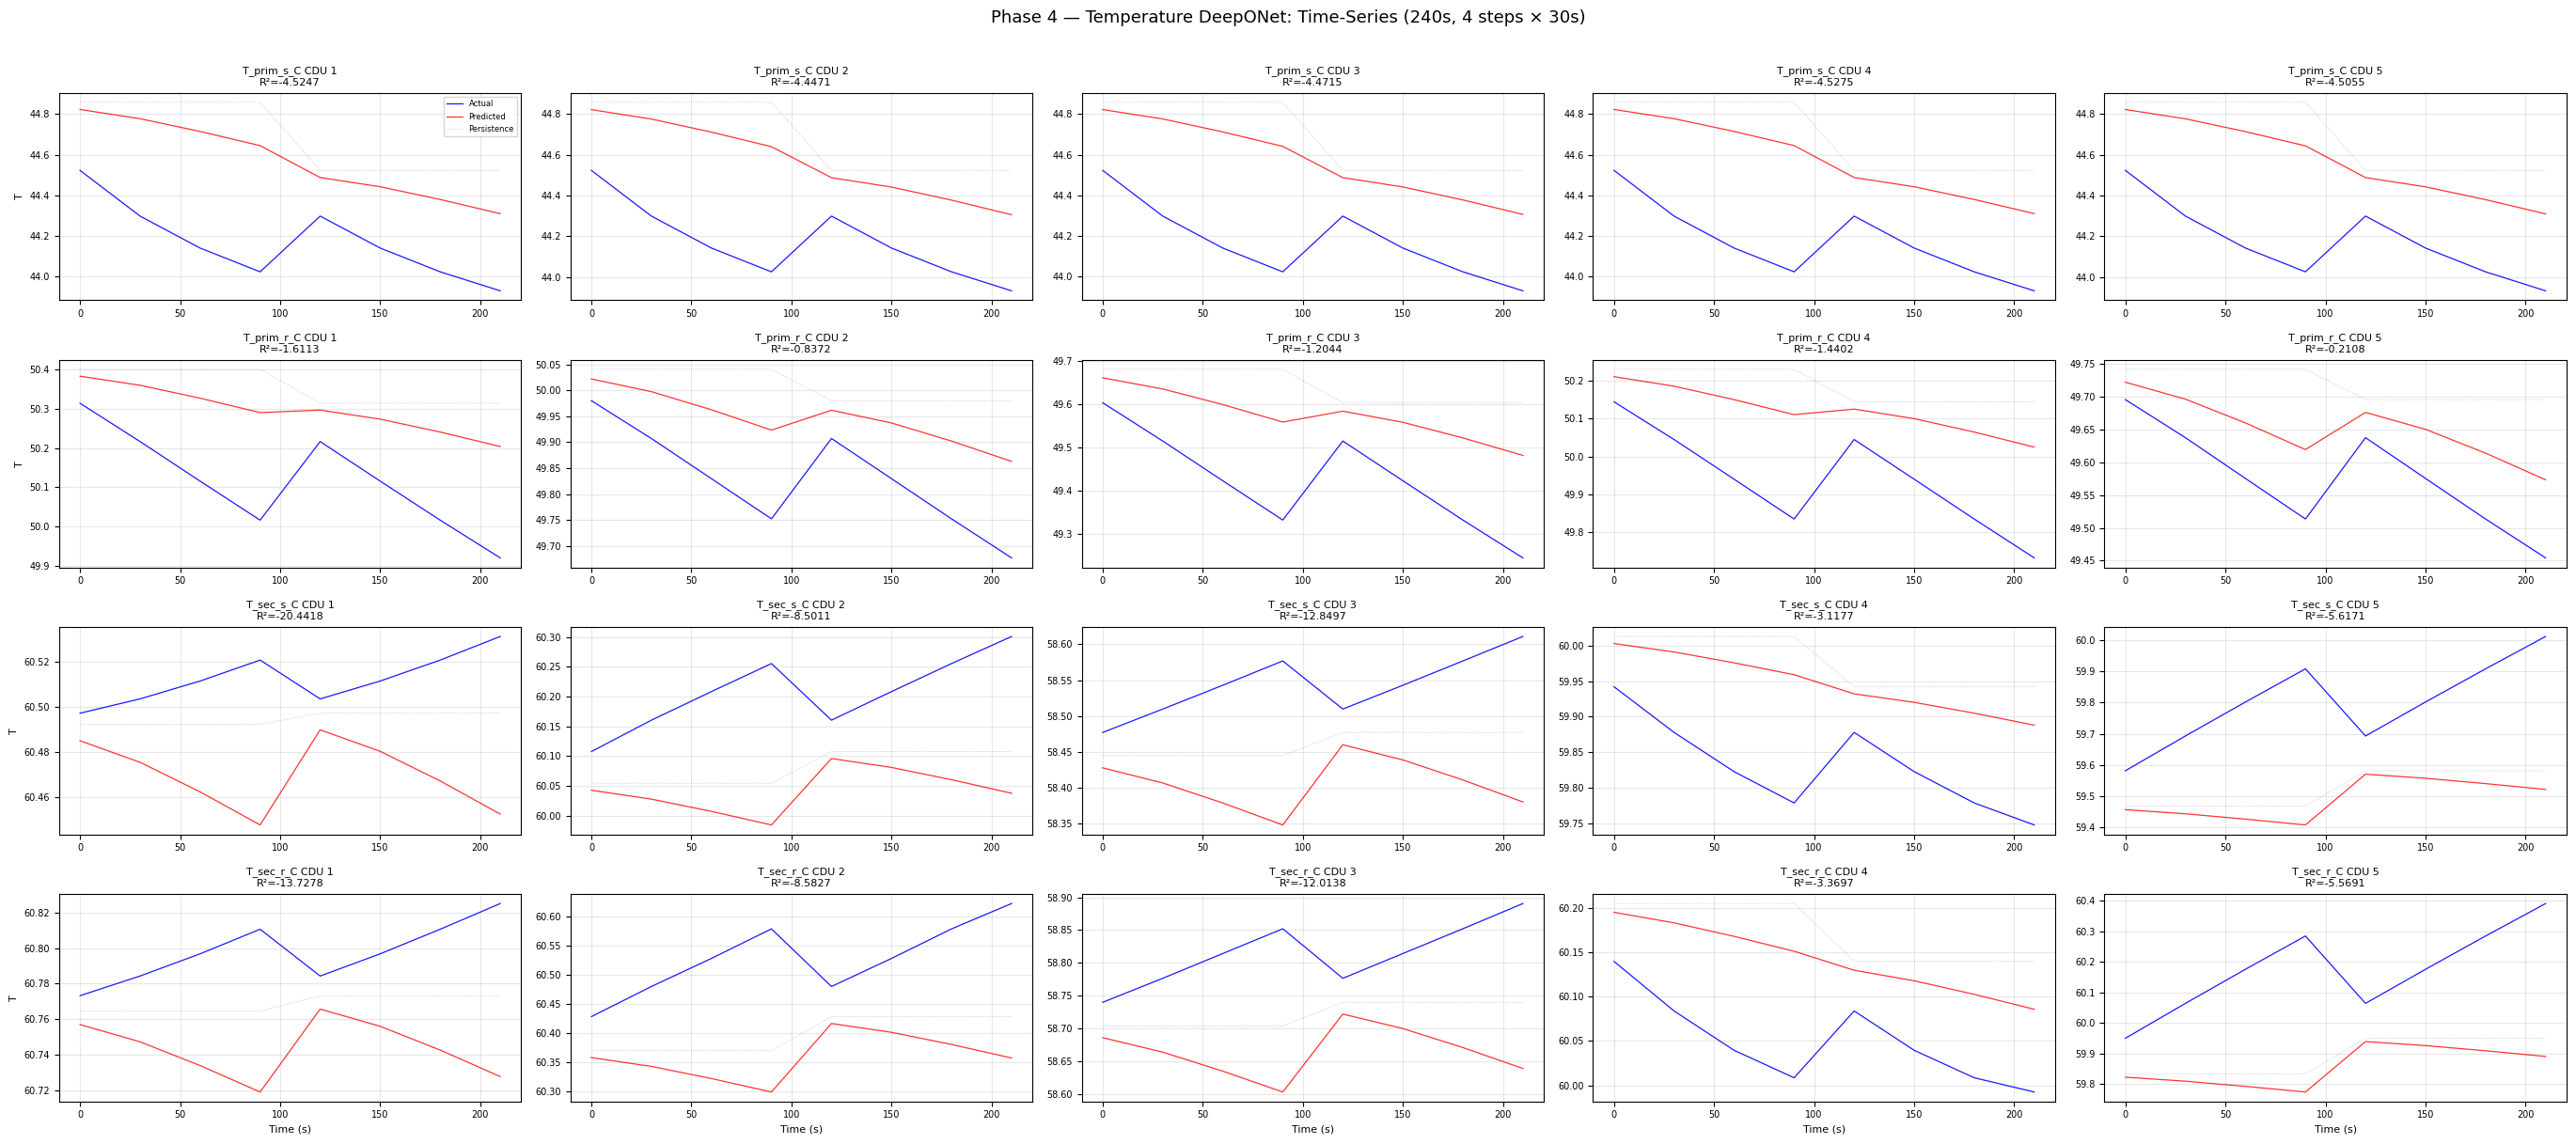

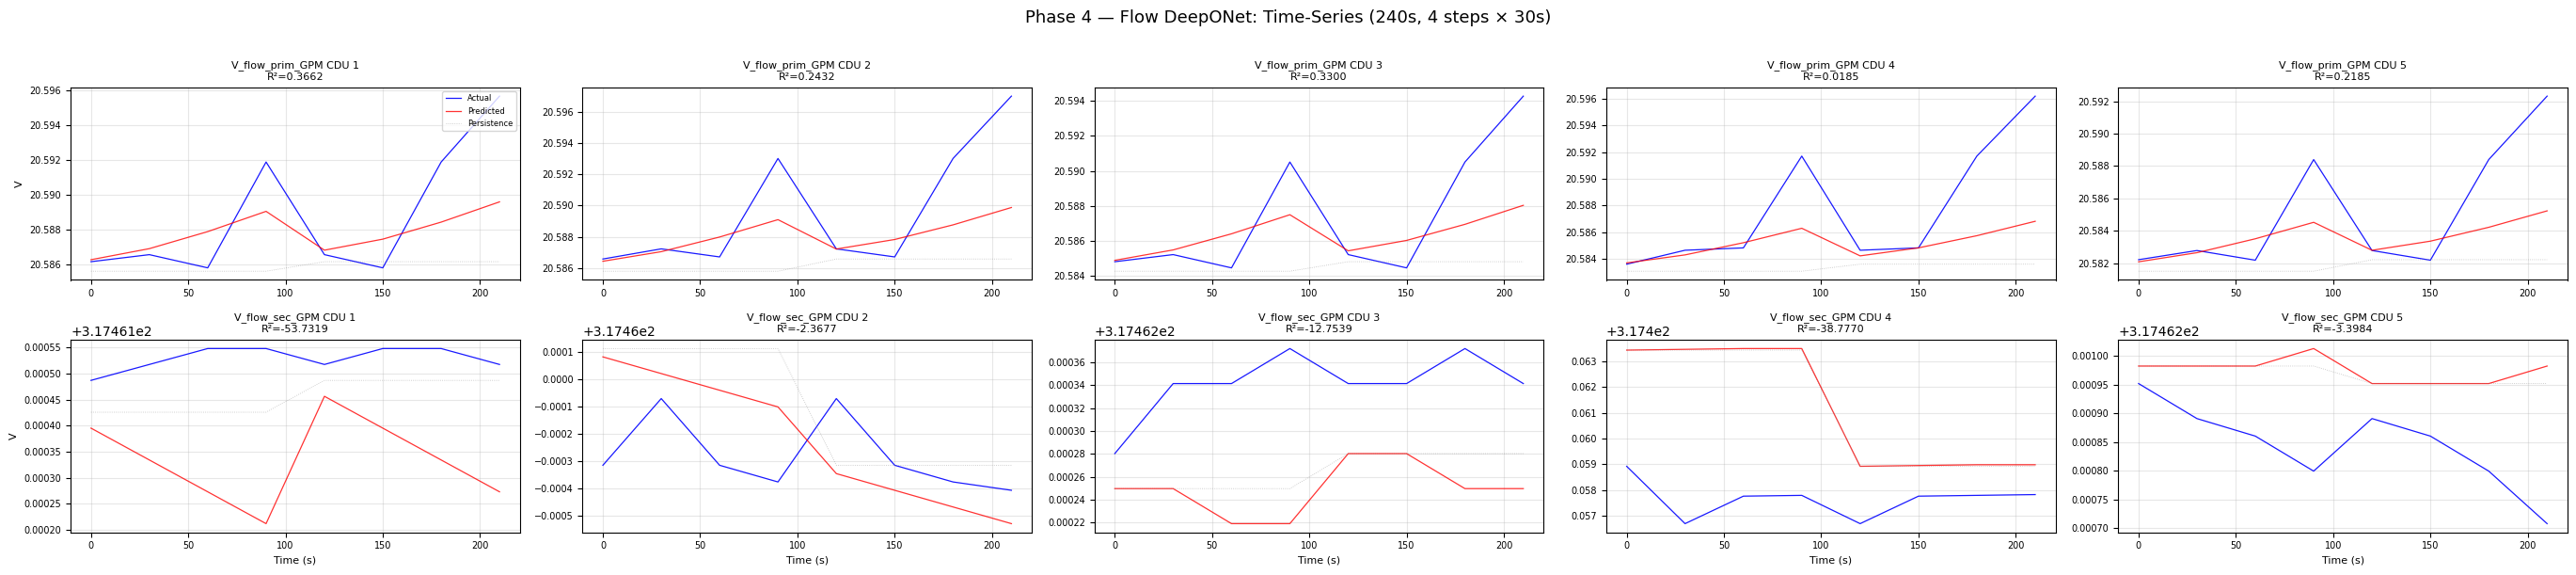

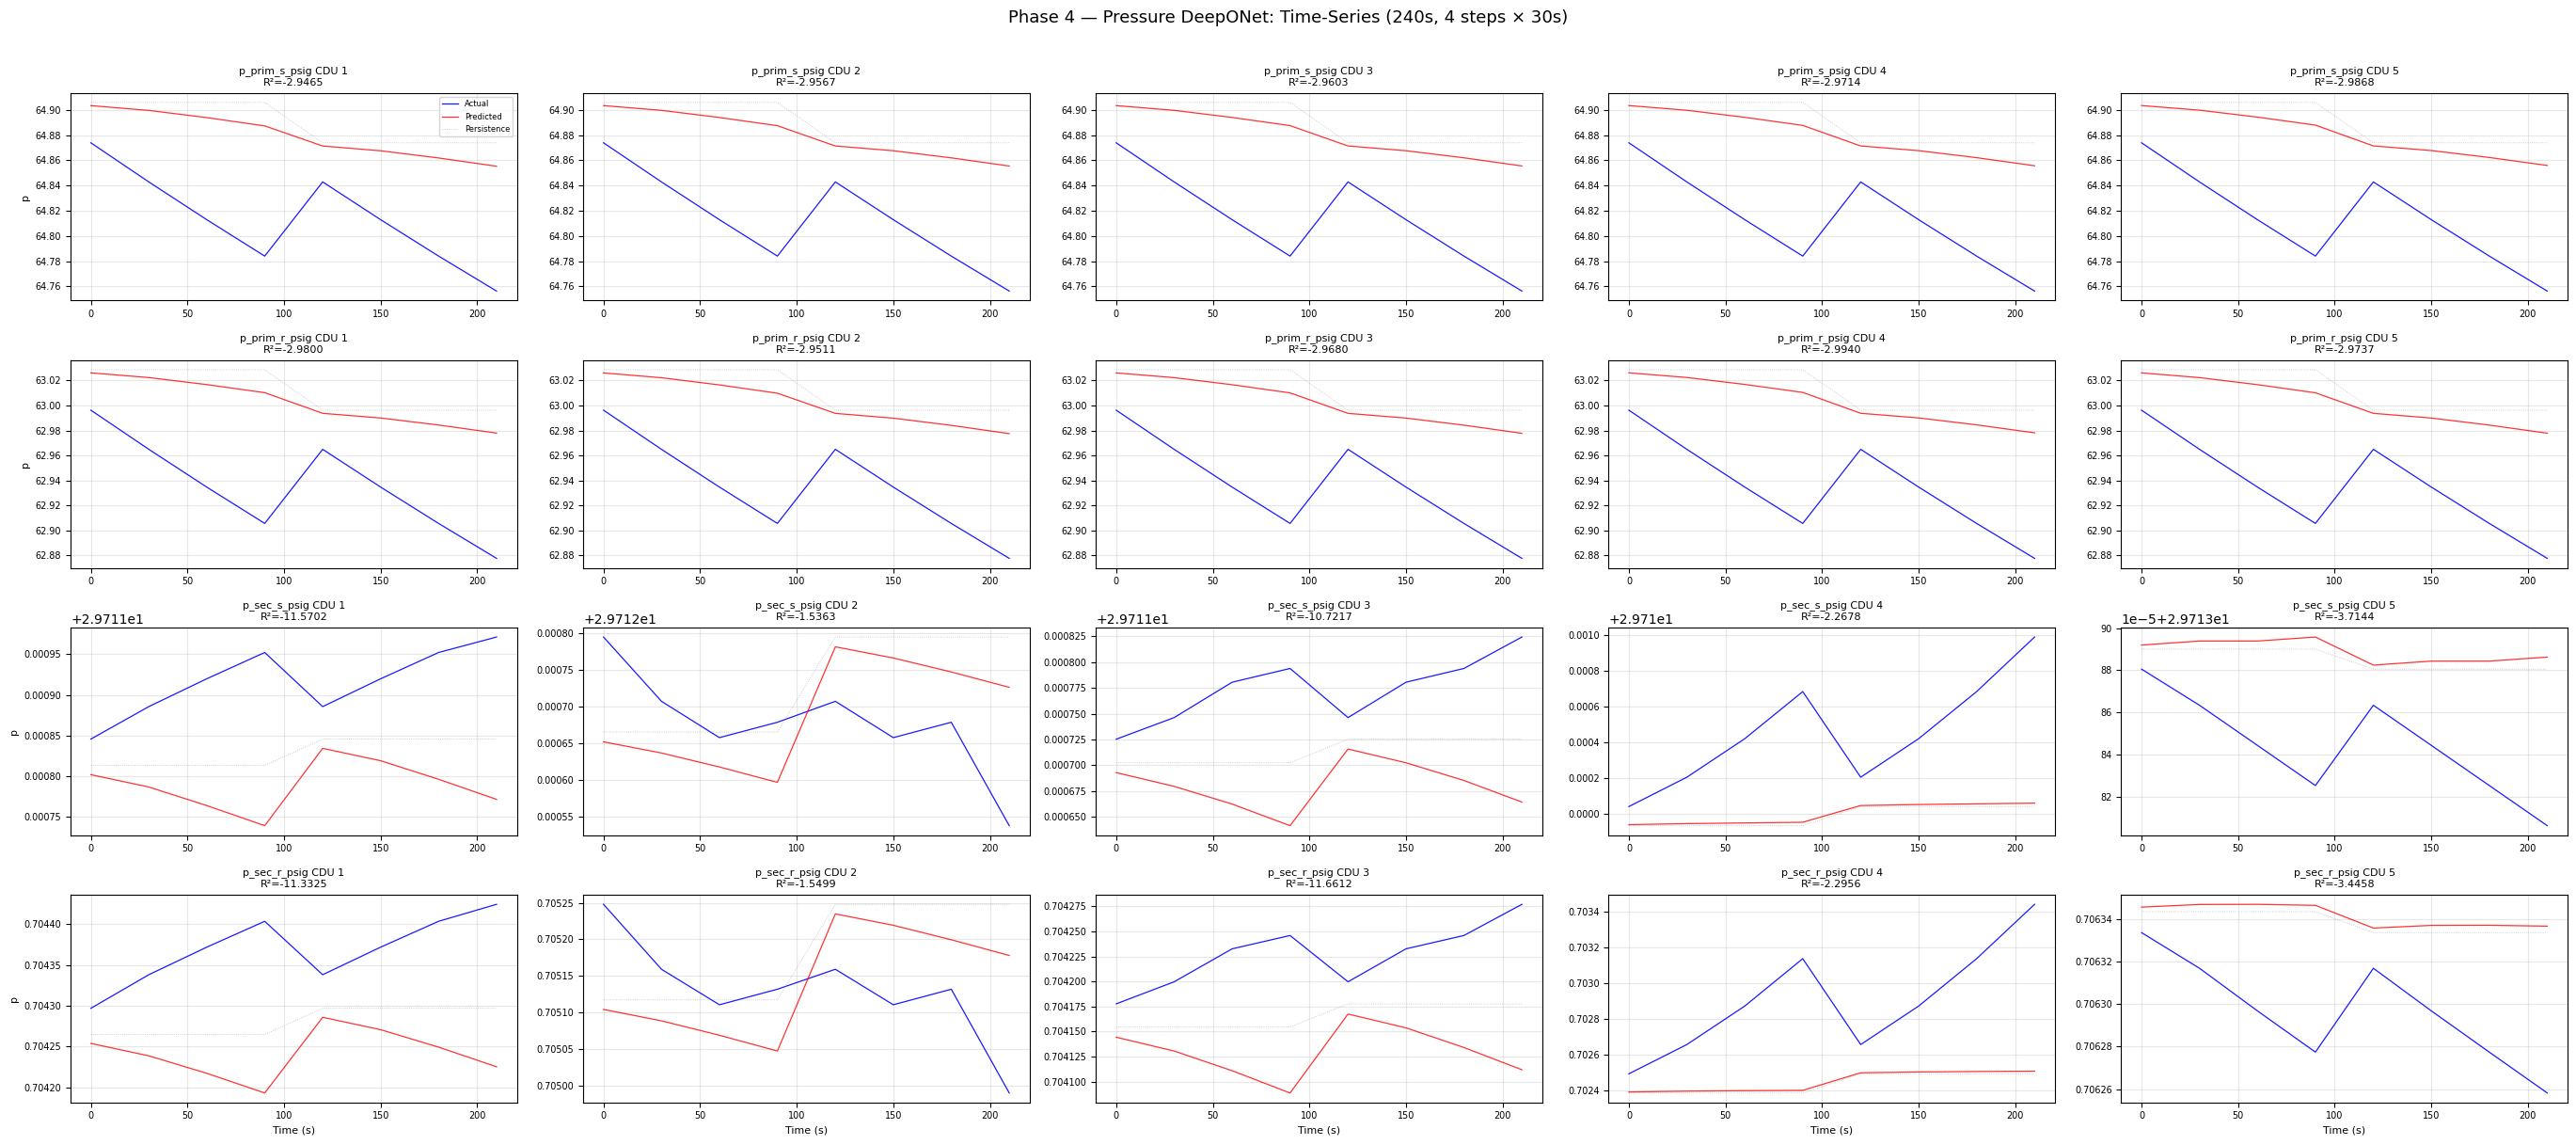

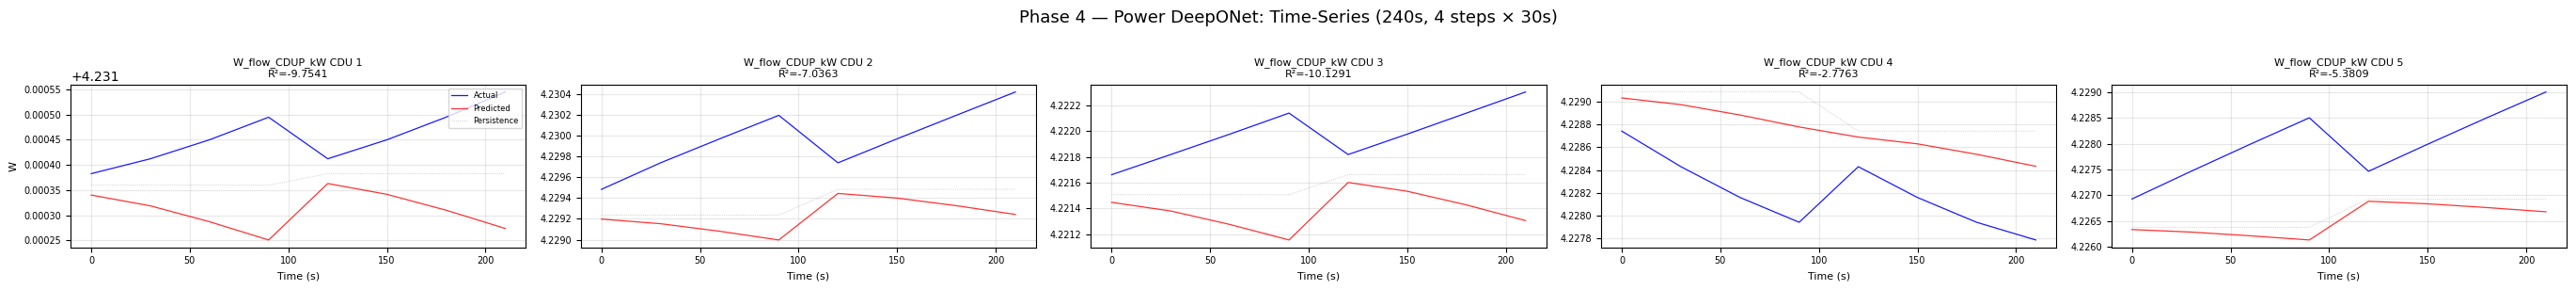

In [ ]:
#  Time-Series Plots — 300-Second Sample per Domain

def plot_timeseries_300s_domain(
    domain_name: str,
    predictions_dict: Dict,
    output_cols: List[str],
    column_info: Dict,
    config,
    n_cdus: int = 5,
    window_seconds: int = 300,
):
    """Plot 300-second time-series: Actual vs Predicted vs Persistence for one domain."""
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_out = predictions_dict['last_output']

    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR
    n_windows = window_seconds // (K * dt)
    N = min(n_windows, pred.shape[0])

    # Get unique output types in this domain
    types_in_domain = list(dict.fromkeys(
        column_info['col_to_type'].get(c, '') for c in output_cols))

    # Select CDUs to plot
    cdu_ids = config.CDU_IDS[:n_cdus]
    n_types = len(types_in_domain)
    n_cdus_plot = len(cdu_ids)

    fig, axes = plt.subplots(n_types, n_cdus_plot,
                             figsize=(5.5 * n_cdus_plot, 3.0 * n_types),
                             squeeze=False)

    output_pattern = 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.{}'

    for row, output_type in enumerate(types_in_domain):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]

            col_name = output_pattern.format(cdu_id, output_type)
            if col_name not in output_cols:
                ax.set_visible(False)
                continue
            oidx = output_cols.index(col_name)

            t_vals, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_vals.append(t_sec)
                    y_actual.append(target[i, k, oidx])
                    y_pred.append(pred[i, k, oidx])
                    y_persist.append(last_out[i, oidx])

            t_vals = np.array(t_vals)
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_vals, y_actual, 'b-', label='Actual', linewidth=0.9, alpha=0.9)
            ax.plot(t_vals, y_pred, 'r-', label='Predicted', linewidth=0.9, alpha=0.8)
            ax.plot(t_vals, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)

            ax.set_title(f'{output_type} CDU {cdu_id}\nR²={r2:.4f}', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type.split('_')[0], fontsize=8)
            if row == n_types - 1:
                ax.set_xlabel('Time (s)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Phase 4 — {domain_name.capitalize()} DeepONet: '
        f'Time-Series ({N * K * dt}s, {K} steps × {dt}s)',
        fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'phase_4_vis/timeseries_{domain_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Plot for each domain
for domain_name in DOMAIN_CONFIGS:
    cols = domain_columns[domain_name]
    cfg = DOMAIN_CONFIGS[domain_name]
    plot_timeseries_300s_domain(
        domain_name,
        domain_predictions[domain_name],
        cols['output_cols'],
        cols['column_info'],
        cfg,
        n_cdus=5)


NEAR-CONSTANT OUTPUT ANALYSIS

  V_flow_sec_GPM (257 outputs):
    Mean R²:          0.6218
    Persistence R²:   0.6231
    Skill Score:      -0.0045
    Beats Persist:    96/257 (37.4%)
    Variance Ratio:   1.0094

  p_sec_s_psig (257 outputs):
    Mean R²:          0.7444
    Persistence R²:   0.7436
    Skill Score:      0.0066
    Beats Persist:    175/257 (68.1%)
    Variance Ratio:   1.0041

  p_sec_r_psig (257 outputs):
    Mean R²:          0.7445
    Persistence R²:   0.7437
    Skill Score:      0.0067
    Beats Persist:    177/257 (68.9%)
    Variance Ratio:   1.0041

  W_flow_CDUP_kW (257 outputs):
    Mean R²:          0.9693
    Persistence R²:   0.9708
    Skill Score:      -0.0418
    Beats Persist:    106/257 (41.2%)
    Variance Ratio:   0.9822


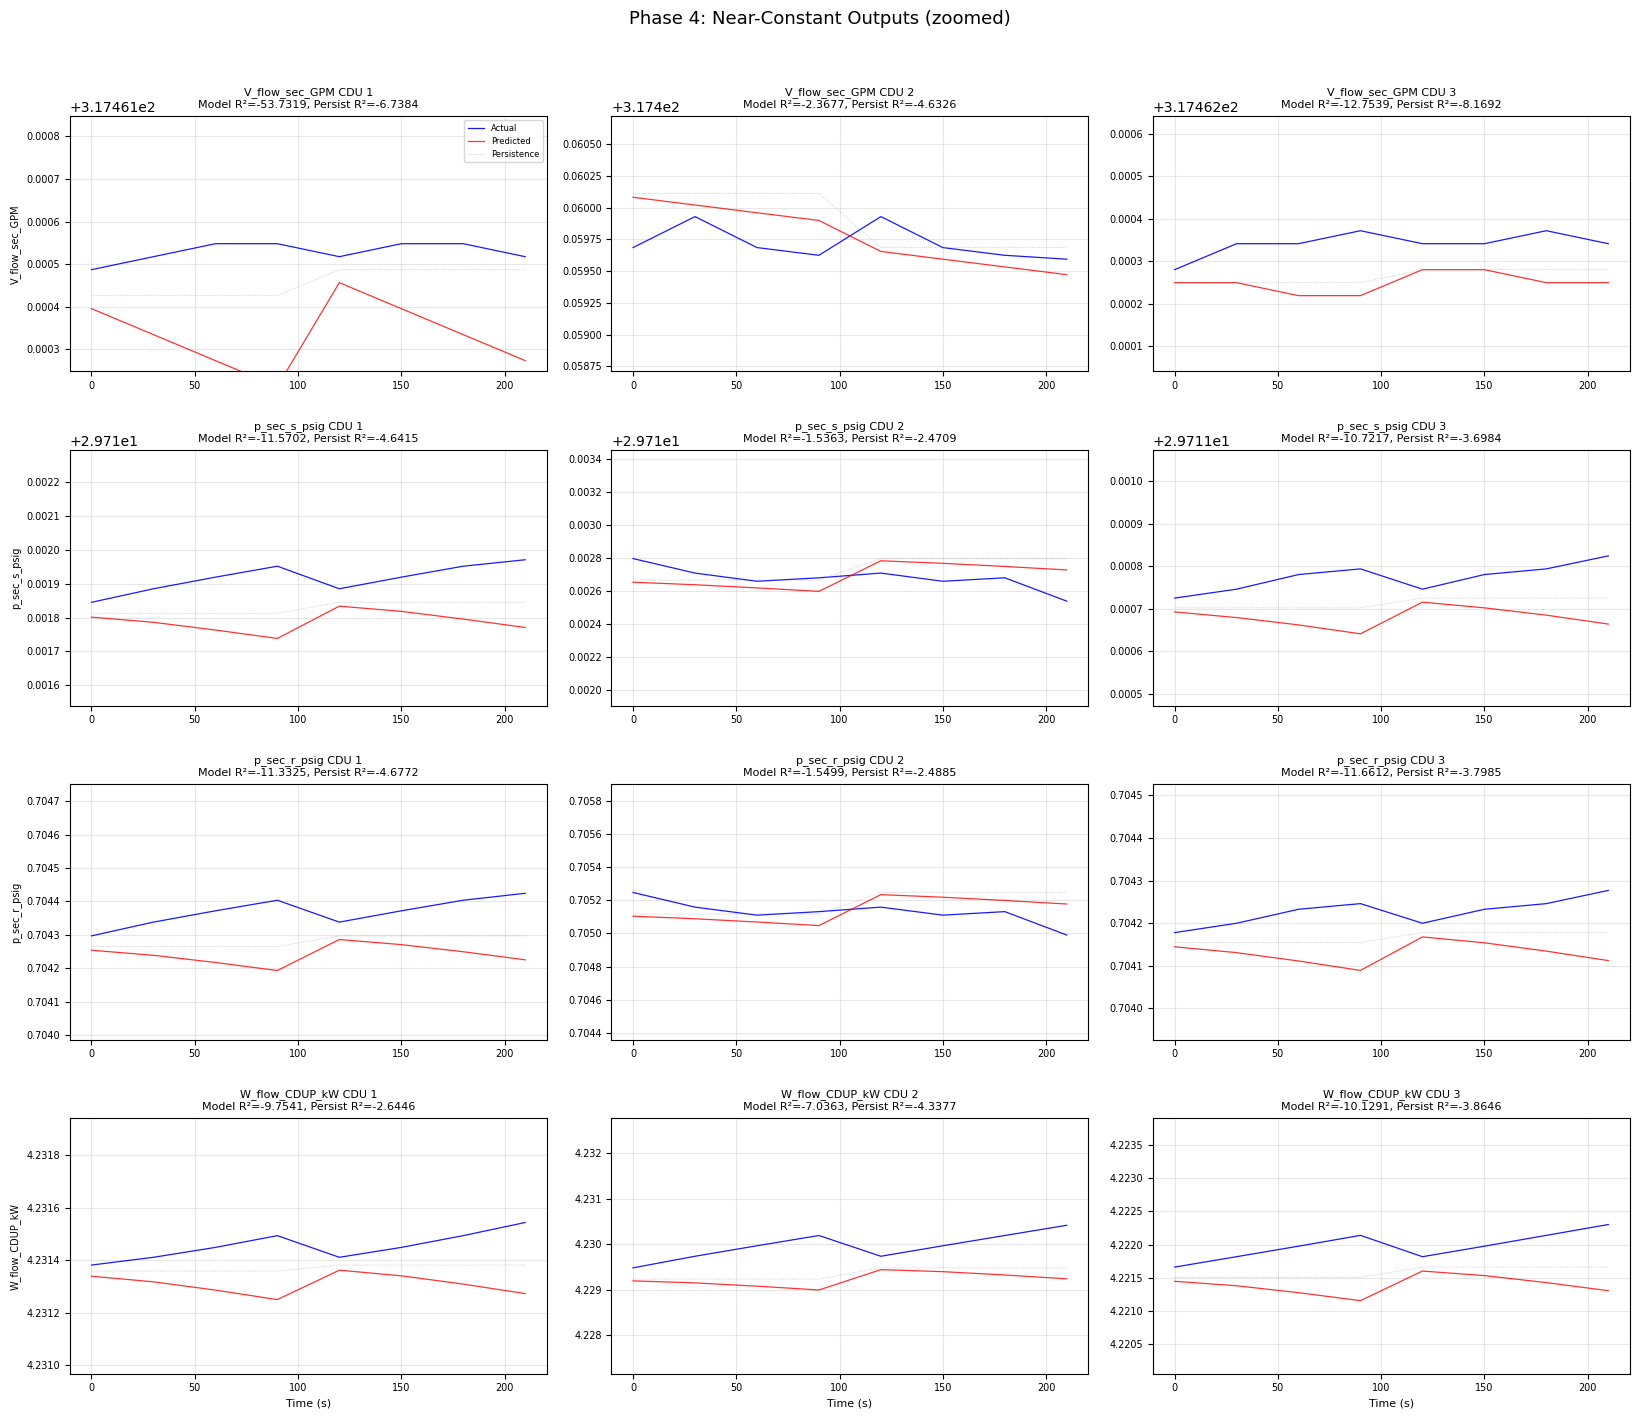

In [ ]:
#  Near-Constant Output Analysis (Secondary Loop, Power)

def plot_near_constant_analysis(
    metrics_df: pd.DataFrame,
    domain_predictions: Dict,
    domain_columns: Dict,
    DOMAIN_CONFIGS: Dict,
    window_seconds: int = 300,
):
    """Dedicated analysis and 300s time-series for near-constant outputs."""

    # Identify near-constant outputs (secondary loop variables and power)
    nearconst_types = ['V_flow_sec_GPM', 'p_sec_s_psig', 'p_sec_r_psig', 'W_flow_CDUP_kW']

    nearconst_df = metrics_df[metrics_df['Type'].isin(nearconst_types)]
    if len(nearconst_df) == 0:
        print("No near-constant output types found.")
        return

    print("\n" + "=" * 70)
    print("NEAR-CONSTANT OUTPUT ANALYSIS")
    print("=" * 70)

    for output_type in nearconst_types:
        type_df = nearconst_df[nearconst_df['Type'] == output_type]
        if len(type_df) == 0:
            continue
        print(f"\n  {output_type} ({len(type_df)} outputs):")
        print(f"    Mean R²:          {type_df['R²'].mean():.4f}")
        print(f"    Persistence R²:   {type_df['Persistence_R²'].mean():.4f}")
        print(f"    Skill Score:      {type_df['Skill_Score'].mean():.4f}")
        print(f"    Beats Persist:    {type_df['Beats_Persistence'].sum()}/{len(type_df)} "
              f"({type_df['Beats_Persistence'].mean():.1%})")
        print(f"    Variance Ratio:   {type_df['Variance_Ratio'].mean():.4f}")

    # Plot zoomed time-series for near-constant outputs
    n_types = len(nearconst_types)
    n_cdus_plot = 3

    fig, axes = plt.subplots(n_types, n_cdus_plot,
                             figsize=(5.5 * n_cdus_plot, 3.5 * n_types),
                             squeeze=False)

    output_pattern = 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.{}'

    for row, output_type in enumerate(nearconst_types):
        type_df = nearconst_df[nearconst_df['Type'] == output_type]
        if len(type_df) == 0:
            for ci in range(n_cdus_plot):
                axes[row, ci].set_visible(False)
            continue

        domain_name = type_df['Domain'].iloc[0]
        cfg = DOMAIN_CONFIGS[domain_name]
        preds = domain_predictions[domain_name]
        cols = domain_columns[domain_name]

        K = cfg.PREDICTION_STEPS
        dt = cfg.SUBSAMPLE_FACTOR
        n_windows = window_seconds // (K * dt)
        N = min(n_windows, preds['pred_absolute'].shape[0])

        cdu_ids = cfg.CDU_IDS[:n_cdus_plot]

        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]

            col_name = output_pattern.format(cdu_id, output_type)
            if col_name not in cols['output_cols']:
                ax.set_visible(False)
                continue
            oidx = cols['output_cols'].index(col_name)

            t_vals, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_vals.append(t_sec)
                    y_actual.append(preds['target_absolute'][i, k, oidx])
                    y_pred.append(preds['pred_absolute'][i, k, oidx])
                    y_persist.append(preds['last_output'][i, oidx])

            t_vals = np.array(t_vals)
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_vals, y_actual, 'b-', label='Actual', linewidth=0.9, alpha=0.9)
            ax.plot(t_vals, y_pred, 'r-', label='Predicted', linewidth=0.9, alpha=0.8)
            ax.plot(t_vals, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            # Zoom to show detail
            y_mean = y_actual.mean()
            y_range = max(y_actual.max() - y_actual.min(), 1e-4)
            margin = y_range * 3
            ax.set_ylim(y_mean - margin, y_mean + margin)

            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)
            ss_res_p = np.sum((y_actual - y_persist) ** 2)
            r2_p = 1 - ss_res_p / (ss_tot + 1e-10)

            ax.set_title(
                f'{output_type} CDU {cdu_id}\nModel R²={r2:.4f}, Persist R²={r2_p:.4f}',
                fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type, fontsize=7)
            if row == n_types - 1:
                ax.set_xlabel('Time (s)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle('Phase 4: Near-Constant Outputs (zoomed)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('phase_4_vis/timeseries_nearconst.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_near_constant_analysis(
    metrics_df, domain_predictions, domain_columns, DOMAIN_CONFIGS)

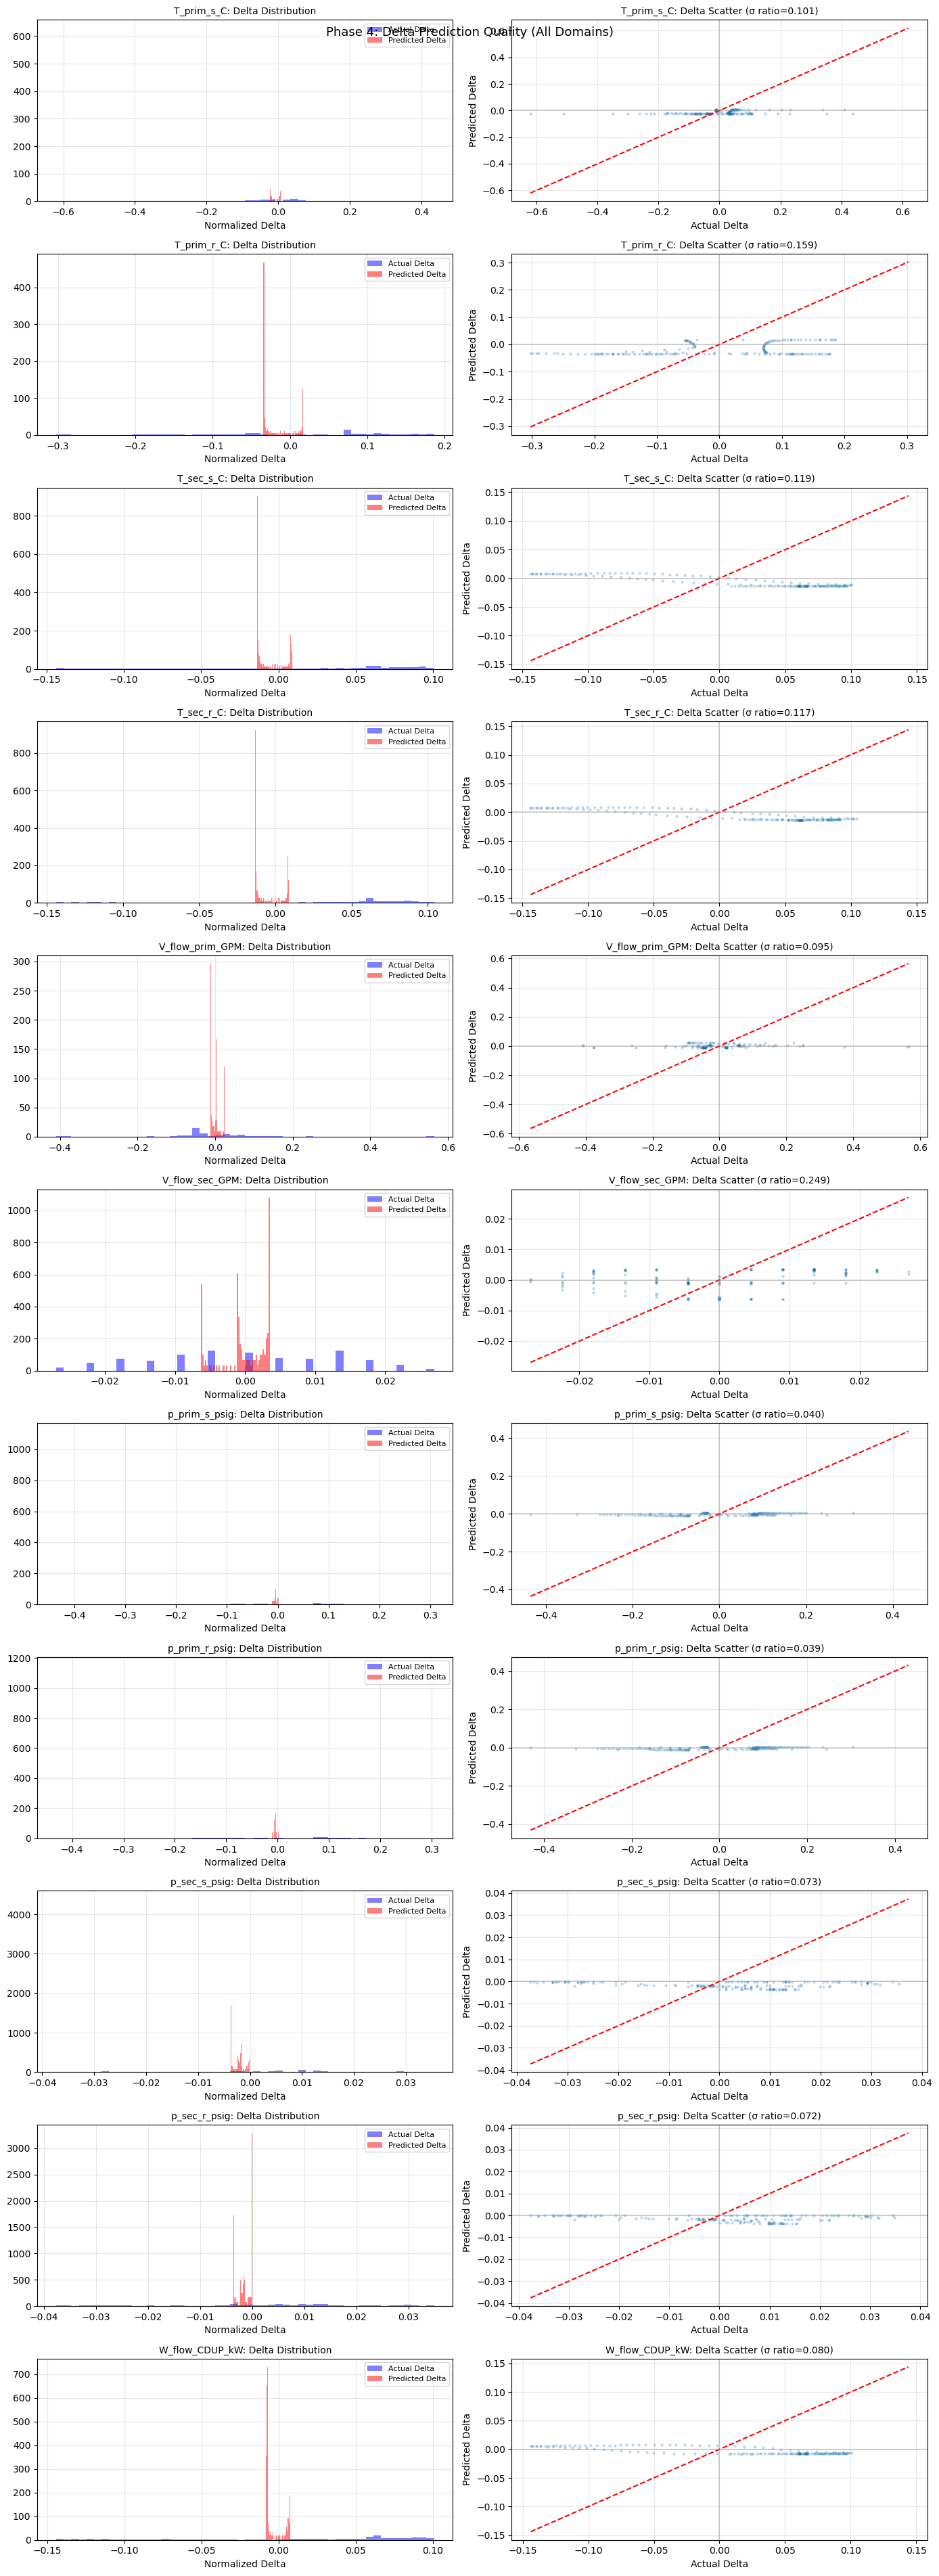

In [ ]:
#  Delta Prediction Quality per Domain

def plot_delta_quality_all_domains(
    domain_predictions: Dict,
    domain_columns: Dict,
    DOMAIN_CONFIGS: Dict,
):
    """Visualize delta prediction quality for all domain models."""

    # Collect one example per output type
    type_examples = {}
    for domain_name in DOMAIN_CONFIGS:
        cols = domain_columns[domain_name]
        preds = domain_predictions[domain_name]
        for i, col in enumerate(cols['output_cols']):
            otype = cols['column_info']['col_to_type'].get(col, 'Unknown')
            if otype not in type_examples:
                type_examples[otype] = {
                    'domain': domain_name,
                    'col_idx': i,
                    'col': col,
                }

    n_types = len(type_examples)
    fig, axes = plt.subplots(n_types, 2, figsize=(14, 3.5 * n_types))
    if n_types == 1:
        axes = axes.reshape(1, -1)

    for row, (otype, info) in enumerate(type_examples.items()):
        preds = domain_predictions[info['domain']]
        ci = info['col_idx']

        pred_d = preds['pred_normalized'][:, 0, ci]
        true_d = preds['target_normalized'][:, 0, ci]

        # Delta distribution
        ax = axes[row, 0]
        ax.hist(true_d, bins=50, alpha=0.5, label='Actual Delta', density=True, color='blue')
        ax.hist(pred_d, bins=50, alpha=0.5, label='Predicted Delta', density=True, color='red')
        ax.set_title(f'{otype}: Delta Distribution', fontsize=10)
        ax.set_xlabel('Normalized Delta')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # Delta scatter
        ax = axes[row, 1]
        n_plot = min(3000, len(pred_d))
        plot_idx = np.random.choice(len(pred_d), n_plot, replace=False)
        ax.scatter(true_d[plot_idx], pred_d[plot_idx], alpha=0.2, s=5)
        lim = max(np.abs(true_d).max(), np.abs(pred_d).max())
        ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5)
        ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
        ax.axvline(0, color='gray', linestyle='-', alpha=0.3)

        std_ratio = np.std(pred_d) / (np.std(true_d) + 1e-10)
        ax.set_title(f'{otype}: Delta Scatter (σ ratio={std_ratio:.3f})', fontsize=10)
        ax.set_xlabel('Actual Delta')
        ax.set_ylabel('Predicted Delta')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Phase 4: Delta Prediction Quality (All Domains)', fontsize=13)
    plt.tight_layout()
    plt.savefig('phase_4_vis/delta_quality.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_delta_quality_all_domains(domain_predictions, domain_columns, DOMAIN_CONFIGS)

## Save Results

In [ ]:
#  Save Models, Metrics, and Training History

import json

save_dir = './saved_models/phase4_domain_specific_deeponet'
os.makedirs(save_dir, exist_ok=True)

# Save each domain model checkpoint
for domain_name, model in domain_models.items():
    config = DOMAIN_CONFIGS[domain_name]
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'config': {
            'HISTORY_STEPS': config.HISTORY_STEPS,
            'N_BASIS': config.N_BASIS,
            # 'LSTM_HIDDEN': config.LSTM_HIDDEN,
            'LSTM_LAYERS': config.LSTM_LAYERS,
            'TRUNK_HIDDEN': config.TRUNK_HIDDEN,
            'N_FOURIER': config.N_FOURIER_FREQ,
            'DROPOUT': config.DROPOUT,
            'USE_SKIP_CONNECTION': config.USE_SKIP_CONNECTION,
            'USE_DERIVATIVE_LOSS': config.USE_DERIVATIVE_LOSS,
            'BATCH_SIZE': config.BATCH_SIZE,
            'LEARNING_RATE': config.LEARNING_RATE,
            'MAX_EPOCHS': config.MAX_EPOCHS,
            'PATIENCE': config.PATIENCE,
        },
        'output_cols': domain_columns[domain_name]['output_cols'],
        'input_cols': domain_columns[domain_name]['input_cols'],
        'n_outputs': len(domain_columns[domain_name]['output_cols']),
        'n_inputs': len(domain_columns[domain_name]['input_cols']),
        'training_time': domain_train_times[domain_name],
        'n_epochs': domain_n_epochs[domain_name],
        'n_params': domain_params[domain_name],
    }
    torch.save(checkpoint, os.path.join(save_dir, f'{domain_name}_model.pt'))
    print(f"Saved {domain_name} model checkpoint")

# Save combined metrics
metrics_df.to_csv(os.path.join(save_dir, 'phase4_metrics.csv'), index=False)
print(f"Saved metrics: {len(metrics_df)} output entries")

# Save training histories
histories_serializable = {}
for domain_name, hist in domain_histories.items():
    histories_serializable[domain_name] = {
        k: [float(v) for v in vals] for k, vals in hist.items()
    }
with open(os.path.join(save_dir, 'phase4_training_histories.json'), 'w') as f:
    json.dump(histories_serializable, f, indent=2)
print(f"Saved training histories")

# Save normalizer states
normalizer_states = {}
for domain_name, norm in domain_normalizers.items():
    input_norm = norm['input']
    domain_norm = norm['domain']
    normalizer_states[domain_name] = {
        'input_stats': input_norm.stats,
        'delta_stats': domain_norm.delta.stats,
    }
with open(os.path.join(save_dir, 'phase4_normalizer_states.json'), 'w') as f:
    json.dump(normalizer_states, f, indent=2)
print(f"Saved normalizer states")

print(f"\nAll results saved to {save_dir}/")

Saved temperature model checkpoint
Saved flow model checkpoint
Saved pressure model checkpoint
Saved power model checkpoint
Saved metrics: 2827 output entries
Saved training histories
Saved normalizer states

All results saved to ./saved_models/phase4_domain_specific_deeponet/


In [ ]:
#  Final Summary

print("=" * 80)
print("PHASE 4: DOMAIN-SPECIFIC DeepONet — FINAL SUMMARY")
print("=" * 80)

# Architecture
print("\n--- Architecture (Per Domain) ---")
for domain_name, config in DOMAIN_CONFIGS.items():
    cols = domain_columns[domain_name]
    n_out = len(cols['output_cols'])
    n_in = len(cols['input_cols'])
    print(f"\n  {domain_name.upper()}:")
    print(f"    Inputs: {n_in} features")
    print(f"    Outputs: {n_out} variables")
    print(f"    LSTM: {config.LSTM_LAYERS} layers, dropout={config.DROPOUT}")
    print(f"    Fourier trunk: {config.N_FOURIER_FREQ} frequencies, {config.TRUNK_HIDDEN} hidden")
    print(f"    Basis functions: {config.N_BASIS}")
    print(f"    History: {config.HISTORY_STEPS} steps ({config.HISTORY_STEPS * 30}s)")
    print(f"    Skip connection: {config.USE_SKIP_CONNECTION}")
    print(f"    Derivative loss: {config.USE_DERIVATIVE_LOSS}")
    print(f"    Parameters: {domain_params[domain_name]['total']} total, {domain_params[domain_name]['trainable']} trainable")

# Training
print("\n--- Training Summary ---")
total_time = sum(domain_train_times.values())
total_params_all = sum(p['total'] for p in domain_params.values())
print(f"  Total parameters (all domains): {total_params_all:,}")
print(f"  Total training time: {total_time:.1f}s ({total_time/60:.1f} min)")
for domain_name in DOMAIN_CONFIGS:
    t = domain_train_times[domain_name]
    e = domain_n_epochs[domain_name]
    print(f"    {domain_name}: {e} epochs, {t:.1f}s ({t/60:.1f} min)")

# Data
print("\n--- Data Summary ---")
print(f"  Dataset: systematic_fmu_output_11hrs.parquet")
print(f"  CDUs: 257")
print(f"  Subsample factor: 30 (dt = 30s)")

# Performance per domain
print("\n--- Performance per Domain ---")
for domain_name in DOMAIN_CONFIGS:
    dm = metrics_df[metrics_df['Domain'] == domain_name]
    r2_med = dm['R\u00b2'].median()
    rmse_med = dm['RMSE'].median()
    skill_med = dm['Skill_Score'].median()
    beats = dm['Beats_Persistence'].mean() * 100
    print(f"\n  {domain_name.upper()}:")
    print(f"    Median R2: {r2_med:.4f}")
    print(f"    Median RMSE: {rmse_med:.6f}")
    print(f"    Median Skill Score: {skill_med:.4f}")
    print(f"    Beats Persistence: {beats:.1f}%")
    for _, row in dm.drop_duplicates('Type').iterrows():
        type_df = dm[dm['Type'] == row['Type']]
        status = "V" if type_df['Beats_Persistence'].mean() > 0.5 else "X"
        print(f"      {row['Type']:20s} R2={type_df['R\u00b2'].mean():.4f}  Skill={type_df['Skill_Score'].mean():.4f}  {status}")

# Primary vs Secondary
print("\n--- Primary vs Secondary Loop ---")
if 'Category' in metrics_df.columns:
    for cat in ['Primary', 'Secondary', 'Single']:
        cm = metrics_df[metrics_df['Category'] == cat]
        if len(cm) > 0:
            print(f"  {cat}: median R2={cm['R\u00b2'].median():.4f}, "
                  f"beats persistence={cm['Beats_Persistence'].mean()*100:.1f}%")

# Near-constant outputs
print("\n--- Near-Constant Outputs ---")
near_const_types = ['V_flow_sec_GPM', 'p_sec_s_psig', 'p_sec_r_psig', 'W_flow_CDUP_kW']
for otype in near_const_types:
    type_rows = metrics_df[metrics_df['Type'] == otype]
    if len(type_rows) > 0:
        r = type_rows.iloc[0]
        status = "MODEL WINS" if r['Beats_Persistence'] else "PERSISTENCE WINS"
        print(f"  {otype:20s}: R2={r['R\u00b2']:.4f}, Persistence R2={r['Persistence_R\u00b2']:.4f}  [{status}]")

# Overall
print("\n--- Overall ---")
print(f"  Mean R2: {metrics_df['R\u00b2'].mean():.4f}")
print(f"  Median R2: {metrics_df['R\u00b2'].median():.4f}")
print(f"  Outputs beating persistence: {metrics_df['Beats_Persistence'].sum()}/{len(metrics_df)}")
print(f"  Mean Skill Score: {metrics_df['Skill_Score'].mean():.4f}")

print("\n" + "=" * 80)
print("Phase 4 notebook complete. Results saved to ./saved_models/phase4_domain_specific_deeponet/")
print("=" * 80)

PHASE 4: DOMAIN-SPECIFIC DeepONet — FINAL SUMMARY

--- Architecture (Per Domain) ---

  TEMPERATURE:
    Inputs: 515 features
    Outputs: 1028 variables
    LSTM: 3 layers, dropout=0.4
    Fourier trunk: 8 frequencies, 64 hidden
    Basis functions: 32
    History: 40 steps (1200s)
    Skip connection: False
    Derivative loss: False
    Parameters: 5399145 total, 5399145 trainable

  FLOW:
    Inputs: 515 features
    Outputs: 514 variables
    LSTM: 2 layers, dropout=0.3
    Fourier trunk: 8 frequencies, 64 hidden
    Basis functions: 32
    History: 60 steps (1800s)
    Skip connection: False
    Derivative loss: True
    Parameters: 2881061 total, 2881061 trainable

  PRESSURE:
    Inputs: 515 features
    Outputs: 1028 variables
    LSTM: 2 layers, dropout=0.3
    Fourier trunk: 8 frequencies, 64 hidden
    Basis functions: 32
    History: 40 steps (1200s)
    Skip connection: True
    Derivative loss: True
    Parameters: 5268077 total, 5268077 trainable

  POWER:
    Inputs: 5